# Stage E — Defenses (Blended Attack)

**Project:** Adaptive Hybrid Machine Unlearning for Backdoor Defense
**Scope:** Fine-Tuning and ANP (Adversarial Neuron Pruning) defenses on Blended-poisoned ResNet-18 checkpoints
**Inputs:** `resnet18_blended_pr01.pth`, `resnet18_blended_pr05.pth`, `resnet18_blended_pr10.pth`, `defense_indices.npy`
**Outputs:** Defended checkpoints, CSV results table

---

This notebook implements **only** Stage E of the pipeline:
1. Load existing poisoned checkpoints (no attack regeneration)
2. Evaluate baseline CA and ASR
3. Apply Fine-Tuning defense
4. Apply ANP (Adversarial Neuron Pruning) defense — Liu et al., NeurIPS 2021
5. Evaluate and save all results

ANP Reference: "Adversarial Neuron Pruning Purifies Backdoored Deep Models"
Implementation adapted from: https://github.com/csdongxian/ANP_backdoor
Cross-referenced with BackdoorBench: https://github.com/SCLBD/BackdoorBench

## Section 1 — Imports & Colab Setup

In [1]:
# ── 1.1  Mount Google Drive ──────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── 1.2  Clone / navigate to the project repository ─────────────────────────
import os

REPO_URL  = "https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git"
REPO_DIR  = "/content/adaptive-backdoor-defense"

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repository already exists at {REPO_DIR}")

%cd {REPO_DIR}

Cloning into '/content/adaptive-backdoor-defense'...
remote: Enumerating objects: 309, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 309 (delta 16), reused 9 (delta 5), pack-reused 279 (from 2)
Receiving objects: 100% (309/309), 165.77 MiB | 14.91 MiB/s, done.
Resolving deltas: 100% (104/104), done.
/content/adaptive-backdoor-defense


In [ ]:
!tar -xzf ./data/cifar-10-python.tar.gz -C ./data

In [4]:
# ── 1.3  Imports ─────────────────────────────────────────────────────────────
import sys
import copy
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset, RandomSampler
from collections import OrderedDict
from PIL import Image
import csv
import matplotlib.pyplot as plt

# Ensure the repo root is on the path so core/ is importable
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# ── Repository imports (reuse existing code — never duplicate) ────────────
from core.models  import get_resnet18
from core.metrics  import calculate_ca, calculate_asr
from core.attacks  import add_blended_trigger_global

print("All imports successful.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

All imports successful.
PyTorch version : 2.11.0+cu128
CUDA available  : True


## Section 2 — Configuration

All tuneable parameters are defined here. **Edit only this cell** to change
experiment settings — no hardcoded values appear elsewhere in the notebook.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit this cell only
# ══════════════════════════════════════════════════════════════════════════════

CFG = {
    # ── Reproducibility ─────────────────────────────────────────────────────
    "SEED":           2027,
    "DEVICE":         "cuda" if torch.cuda.is_available() else "cpu",

    # ── Data ────────────────────────────────────────────────────────────────
    "BATCH_SIZE":     128,
    "NUM_WORKERS":    2,
    "TARGET_CLASS":   0,          # Airplane — fixed across entire project
    "NUM_CLASSES":    10,

    # ── Fine-Tuning ────────────────────────────────────────────────────────
    "FT_LR":          1e-4,       # Low LR per docs (1e-4 to 1e-3)
    "FT_EPOCHS":      15,         # Few epochs per docs (5–15)
    "FT_PATIENCE":    3,          # Early stopping patience (epochs)
    "OPTIMIZER":      "SGD",      # "SGD" or "Adam" — configurable
    "SGD_MOMENTUM":   0.9,        # Only used when OPTIMIZER == "SGD"
    "WEIGHT_DECAY":   5e-4,       # Standard regularisation

    # ── Validation split (optional) ────────────────────────────────────────
    # If False: all 2,500 defense images are used for training (no val set,
    #           no early stopping). Matches the project docs most closely.
    # If True:  80/20 split → 2,000 train / 500 val, early stopping enabled.
    "USE_VALIDATION": False,
    "VAL_SPLIT":      0.2,

    # ══════════════════════════════════════════════════════════════════════════
    # ANP (Adversarial Neuron Pruning) — Liu et al., NeurIPS 2021
    # Hyperparameters sourced from the official implementation:
    #   https://github.com/csdongxian/ANP_backdoor/blob/main/optimize_mask_cifar.py
    #   https://github.com/csdongxian/ANP_backdoor/blob/main/prune_neuron_cifar.py
    # ══════════════════════════════════════════════════════════════════════════

    # ── Mask optimisation ──────────────────────────────────────────────────
    "ANP_EPS":        0.4,        # Official default: perturbation budget for neuron noise
    "ANP_STEPS":      1,          # Official default: inner adversarial steps per iteration
    "ANP_ALPHA":      0.2,        # Official default: α·L_clean + (1-α)·L_robust
    "ANP_LR":         0.2,        # Official default: learning rate for mask SGD optimiser
    "ANP_NB_ITER":    2000,       # Official default: total mask optimisation iterations
    "ANP_BATCH_SIZE": 128,        # Official default: batch size for mask optimisation
    "ANP_PRINT_EVERY": 500,       # Official default: log frequency during optimisation

    # ── Pruning sweep ──────────────────────────────────────────────────────
    "PRUNING_BY":     "threshold", # Official default: prune by mask-score threshold
    "PRUNING_MAX":    0.90,        # Official default: max pruning threshold to evaluate
    "PRUNING_STEP":   0.05,        # Official default: step size for threshold sweep

    # ── Operating point selection ──────────────────────────────────────────
    "MAX_CA_DROP":    5.0,         # Max allowable CA drop (pp) for auto-selecting threshold

    # ── ASR evaluation ─────────────────────────────────────────────────────
    # Matched-to-training alpha (doc: blended_stage_C_status.md)
    "ALPHA_TEST":     0.1,

    # ── Paths (Google Drive) ───────────────────────────────────────────────
    "DRIVE_BASE":           "/content/drive/MyDrive/ps-capstone1",
    "DEFENSE_INDICES_PATH": "/content/drive/MyDrive/ps-capstone1/defense_indices.npy",
    "BLEND_PATTERN_PATH":   "/content/drive/MyDrive/ps-capstone1/blended_pattern_seed777.npy",
    "OUTPUT_DIR":           "/content/drive/MyDrive/ps-capstone1/defended_checkpoints",

    # ── Checkpoints to process ─────────────────────────────────────────────
    "CHECKPOINTS": {
        "1%":  "resnet18_blended_pr01.pth",
        "5%":  "resnet18_blended_pr05.pth",
        "10%": "resnet18_blended_pr10.pth",
    },
}

# Derived paths
CFG["CKPT_DIR"] = CFG["DRIVE_BASE"]

print("Configuration loaded.")
for k, v in CFG.items():
    if k != "CHECKPOINTS":
        print(f"  {k:25s} = {v}")
print(f"  {'CHECKPOINTS':25s} = {list(CFG['CHECKPOINTS'].keys())}")

Configuration loaded.
  SEED                      = 2027
  DEVICE                    = cuda
  BATCH_SIZE                = 128
  NUM_WORKERS               = 2
  TARGET_CLASS              = 0
  NUM_CLASSES               = 10
  FT_LR                     = 0.0001
  FT_EPOCHS                 = 15
  FT_PATIENCE               = 3
  OPTIMIZER                 = SGD
  SGD_MOMENTUM              = 0.9
  WEIGHT_DECAY              = 0.0005
  USE_VALIDATION            = False
  VAL_SPLIT                 = 0.2
  ANP_EPS                   = 0.4
  ANP_STEPS                 = 1
  ANP_ALPHA                 = 0.2
  ANP_LR                    = 0.2
  ANP_NB_ITER               = 2000
  ANP_BATCH_SIZE            = 128
  ANP_PRINT_EVERY           = 500
  PRUNING_BY                = threshold
  PRUNING_MAX               = 0.9
  PRUNING_STEP              = 0.05
  MAX_CA_DROP               = 5.0
  ALPHA_TEST                = 0.1
  DRIVE_BASE                = /content/drive/MyDrive/ps-capstone1
  DEFENSE_INDICES_PA

## Section 3 — Reproducibility Setup

Global seed from `docs/06_EXPERIMENT_PROTOCOL_AND_REPRODUCIBILITY.md`.

In [ ]:
# ── 3.  Set global seed (doc 06 specification) ───────────────────────────────
import random

def set_seed(seed=2027):
    """Exact function from docs/06_EXPERIMENT_PROTOCOL_AND_REPRODUCIBILITY.md."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True  # crucial for reproducibility

set_seed(CFG["SEED"])
print(f"Global seed set to {CFG['SEED']}")
print(f"Device: {CFG['DEVICE']}")

Global seed set to 2027
Device: cuda


## Section 4 — Load CIFAR-10

In [11]:
# ── 4.  CIFAR-10 transforms and datasets ─────────────────────────────────────

import shutil
import os
import glob

# User provided link: https://drive.google.com/drive/folders/1KGhC2ff_44927XlkxihBvX1dznIniTKJ
# We will search for the folder content in Drive
LOCAL_DATA_DIR = "./data"
local_dataset_path = os.path.join(LOCAL_DATA_DIR, "cifar-10-batches-py")

# Ensure local data directory exists
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if not os.path.exists(local_dataset_path):
    # Search for the folder in Drive
    search_path = "/content/drive/MyDrive/**/cifar-10-batches-py"
    search_results = glob.glob(search_path, recursive=True)

    if not search_results:
        # Try searching for a folder that contains the batches
        search_path = "/content/drive/MyDrive/**/data_batch_1"
        search_results = [os.path.dirname(p) for p in glob.glob(search_path, recursive=True)]

    if search_results:
        drive_src = search_results[0]
        print(f"Found CIFAR-10 at: {drive_src}")
        print("Copying to local storage...")
        shutil.copytree(drive_src, local_dataset_path, dirs_exist_ok=True)
    else:
        raise FileNotFoundError("Could not locate CIFAR-10 data in /content/drive/MyDrive/. Please ensure the Drive is mounted and the folder is shared correctly.")

# Standard CIFAR-10 normalisation
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# ── ANP-specific transform ──
transform_anp_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Load dataset from local path (download=False)
trainset_transformed = torchvision.datasets.CIFAR10(
    root=LOCAL_DATA_DIR, train=True, download=False, transform=transform_train
)

trainset_anp = torchvision.datasets.CIFAR10(
    root=LOCAL_DATA_DIR, train=True, download=False, transform=transform_anp_train
)

testset = torchvision.datasets.CIFAR10(
    root=LOCAL_DATA_DIR, train=False, download=False, transform=transform_test
)

testset_raw = torchvision.datasets.CIFAR10(
    root=LOCAL_DATA_DIR, train=False, download=False, transform=None
)

clean_test_loader = DataLoader(
    testset,
    batch_size=CFG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CFG["NUM_WORKERS"],
)

print(f"CIFAR-10 train set : {len(trainset_transformed):,} images")
print(f"CIFAR-10 test set  : {len(testset):,} images")
print(f"Clean test loader  : {len(clean_test_loader)} batches")

Found CIFAR-10 at: /content/drive/MyDrive/Capstone /old drive content/datasets/cifar-10-batches-py
Copying to local storage...
CIFAR-10 train set : 50,000 images
CIFAR-10 test set  : 10,000 images
Clean test loader  : 79 batches


## Section 5 — Load Defense Indices & Build Defense Subset

Uses the shared `defense_indices.npy` (2,500 fixed clean CIFAR-10 training images).
Per project docs: **never regenerate, never reshuffle — always use the supplied indices.**

In [12]:
# ── 5.  Load defense indices and build defense DataLoader(s) ──────────────────

defense_indices = np.load(CFG["DEFENSE_INDICES_PATH"])
print(f"Defense indices loaded: {len(defense_indices)} images")
assert len(defense_indices) == 2500, (
    f"Expected 2,500 defense indices, got {len(defense_indices)}. "
    f"Check {CFG['DEFENSE_INDICES_PATH']}"
)

# Build the defense subset from CIFAR-10 train with transforms
defense_subset = Subset(trainset_transformed, defense_indices.tolist())

# Build the ANP defense subset (with augmentation)
defense_subset_anp = Subset(trainset_anp, defense_indices.tolist())

if CFG["USE_VALIDATION"]:
    # ── Optional 80/20 split for early stopping ──────────────────────────
    n_val   = int(len(defense_subset) * CFG["VAL_SPLIT"])
    n_train = len(defense_subset) - n_val

    # Deterministic split using the global seed
    gen = torch.Generator().manual_seed(CFG["SEED"])
    defense_train_subset, defense_val_subset = torch.utils.data.random_split(
        defense_subset, [n_train, n_val], generator=gen
    )

    defense_train_loader = DataLoader(
        defense_train_subset,
        batch_size=CFG["BATCH_SIZE"],
        shuffle=True,
        num_workers=CFG["NUM_WORKERS"],
    )
    defense_val_loader = DataLoader(
        defense_val_subset,
        batch_size=CFG["BATCH_SIZE"],
        shuffle=False,
        num_workers=CFG["NUM_WORKERS"],
    )
    print(f"Validation enabled: {n_train} train / {n_val} val")
else:
    # ── Use all 2,500 for training (no early stopping) ──────────────────
    defense_train_loader = DataLoader(
        defense_subset,
        batch_size=CFG["BATCH_SIZE"],
        shuffle=True,
        num_workers=CFG["NUM_WORKERS"],
    )
    defense_val_loader = None
    print(f"Validation disabled: all {len(defense_subset)} images used for training")

print(f"Defense train loader : {len(defense_train_loader)} batches")
if defense_val_loader:
    print(f"Defense val loader   : {len(defense_val_loader)} batches")

Defense indices loaded: 2500 images
Validation disabled: all 2500 images used for training
Defense train loader : 20 batches


## Section 6 — Build ASR Test Set (Graceful Fallback)

ASR evaluation requires the blend pattern file (`blended_pattern_seed777.npy`).
If the file is available, we build a triggered test set using the existing
`core.attacks.add_blended_trigger_global` function. If not, ASR is set to `None`
and the rest of the notebook runs without breaking.

In [13]:
# ── 6.  ASR test set construction ────────────────────────────────────────────

class TriggeredDataset(Dataset):
    """Wraps non-target-class test images with the Blended trigger applied.

    Uses the existing `add_blended_trigger_global` from core/attacks.py —
    no duplicate trigger logic.
    """
    def __init__(self, base_dataset_raw, pattern, alpha, target_class, transform):
        self.base      = base_dataset_raw
        self.pattern   = pattern
        self.alpha     = alpha
        self.transform = transform
        # Only use non-target-class images (per doc 06 Step 5)
        self.indices = [
            i for i in range(len(base_dataset_raw))
            if base_dataset_raw.targets[i] != target_class
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_pil, _ = self.base[real_idx]
        img_np = np.array(img_pil)  # (H, W, 3) uint8
        # Apply trigger using existing repository function
        img_triggered = add_blended_trigger_global(img_np, self.pattern, self.alpha)
        img_pil_trig  = Image.fromarray(img_triggered)
        if self.transform:
            img_pil_trig = self.transform(img_pil_trig)
        return img_pil_trig, 0  # label unused by calculate_asr


# Attempt to load blend pattern
blend_pattern = None
asr_test_loader = None

if os.path.isfile(CFG["BLEND_PATTERN_PATH"]):
    blend_pattern = np.load(CFG["BLEND_PATTERN_PATH"])
    print(f"Blend pattern loaded: shape={blend_pattern.shape}, dtype={blend_pattern.dtype}")

    triggered_dataset = TriggeredDataset(
        base_dataset_raw=testset_raw,
        pattern=blend_pattern,
        alpha=CFG["ALPHA_TEST"],
        target_class=CFG["TARGET_CLASS"],
        transform=transform_test,
    )
    asr_test_loader = DataLoader(
        triggered_dataset,
        batch_size=CFG["BATCH_SIZE"],
        shuffle=False,
        num_workers=CFG["NUM_WORKERS"],
    )
    print(f"ASR test loader ready: {len(triggered_dataset)} triggered images, "
          f"{len(asr_test_loader)} batches")
else:
    print(f"⚠️  Blend pattern NOT found at {CFG['BLEND_PATTERN_PATH']}")
    print("   ASR will be reported as None. Upload blended_pattern_seed777.npy ")
    print("   to the Drive path above and re-run this cell to enable ASR evaluation.")

Blend pattern loaded: shape=(32, 32, 3), dtype=float32
ASR test loader ready: 9000 triggered images, 71 batches


## Section 7 — Helper Functions

Modular helpers for checkpoint I/O, evaluation, fine-tuning, and ANP.
Each defense (FT, ANP) calls these independently.

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.1  Checkpoint loading (robust — supports both state_dict formats)
# ══════════════════════════════════════════════════════════════════════════════

def load_checkpoint(path, device=None):
    """Load a poisoned ResNet-18 checkpoint.

    Supports two common save formats:
      1. torch.save(model.state_dict(), path)         → raw OrderedDict
      2. torch.save({"model_state_dict": ...}, path)  → wrapped dict

    Returns the model on `device`, in eval mode.
    """
    if device is None:
        device = CFG["DEVICE"]

    model = get_resnet18(num_classes=CFG["NUM_CLASSES"])
    ckpt  = torch.load(path, map_location=device)

    # Auto-detect format
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        # Assume raw state_dict
        state_dict = ckpt

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


# ══════════════════════════════════════════════════════════════════════════════
# 7.2  Evaluation wrapper (reuses core.metrics — no duplication)
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_model(model, clean_loader, asr_loader=None,
                   target_class=None, device=None):
    """Evaluate Clean Accuracy and (optionally) ASR.

    Returns dict: {"CA": float, "ASR": float or None}
    Uses calculate_ca / calculate_asr from core.metrics.
    """
    if target_class is None:
        target_class = CFG["TARGET_CLASS"]
    if device is None:
        device = CFG["DEVICE"]

    ca = calculate_ca(model, clean_loader, device)

    asr = None
    if asr_loader is not None:
        asr = calculate_asr(model, asr_loader, target_class, device)

    return {"CA": ca, "ASR": asr}


# ══════════════════════════════════════════════════════════════════════════════
# 7.3  Optimizer factory
# ══════════════════════════════════════════════════════════════════════════════

def make_optimizer(model, lr=None, optimizer_name=None):
    """Construct optimizer based on CFG['OPTIMIZER'].

    Supports 'SGD' and 'Adam'. Configurable from the configuration cell.
    """
    if lr is None:
        lr = CFG["FT_LR"]
    if optimizer_name is None:
        optimizer_name = CFG["OPTIMIZER"]

    if optimizer_name.upper() == "SGD":
        return torch.optim.SGD(
            model.parameters(), lr=lr,
            momentum=CFG["SGD_MOMENTUM"],
            weight_decay=CFG["WEIGHT_DECAY"],
        )
    elif optimizer_name.upper() == "ADAM":
        return torch.optim.Adam(
            model.parameters(), lr=lr,
            weight_decay=CFG["WEIGHT_DECAY"],
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}. Use 'SGD' or 'Adam'.")


# ══════════════════════════════════════════════════════════════════════════════
# 7.4  Fine-Tuning
# ══════════════════════════════════════════════════════════════════════════════

def fine_tune(model, train_loader, val_loader=None,
              lr=None, epochs=None, patience=None, device=None):
    """Fine-tune a model on the clean defense subset.

    Implements:
      - Low learning rate (configurable, default 1e-4)
      - Few epochs (configurable, default 15)
      - Early stopping if USE_VALIDATION is True and val_loader is provided

    Args:
        model:        Model to fine-tune (modified in-place).
        train_loader: Defense training DataLoader.
        val_loader:   Optional validation DataLoader for early stopping.
        lr:           Learning rate (defaults to CFG['FT_LR']).
        epochs:       Max epochs (defaults to CFG['FT_EPOCHS']).
        patience:     Early stopping patience (defaults to CFG['FT_PATIENCE']).
        device:       Device string.

    Returns:
        model:   The fine-tuned model.
        history: List of dicts with per-epoch train_loss, train_ca, val_ca.
    """
    if lr is None:
        lr = CFG["FT_LR"]
    if epochs is None:
        epochs = CFG["FT_EPOCHS"]
    if patience is None:
        patience = CFG["FT_PATIENCE"]
    if device is None:
        device = CFG["DEVICE"]

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, lr=lr)

    history     = []
    best_val_ca = 0.0
    wait        = 0
    best_state  = None

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────────────────
        model.train()
        running_loss    = 0.0
        correct, total  = 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss    = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            correct      += (outputs.argmax(1) == y).sum().item()
            total        += y.size(0)

        train_loss = running_loss / total
        train_ca   = correct / total

        # ── Validate (if enabled) ────────────────────────────────────────
        val_ca = None
        if val_loader is not None:
            val_ca = calculate_ca(model, val_loader, device)

        epoch_info = {
            "epoch":      epoch,
            "train_loss": round(train_loss, 4),
            "train_ca":   round(train_ca, 4),
            "val_ca":     round(val_ca, 4) if val_ca is not None else None,
        }
        history.append(epoch_info)

        # ── Logging ──────────────────────────────────────────────────────
        msg = (f"  Epoch {epoch:2d}/{epochs} — "
               f"loss: {train_loss:.4f}, "
               f"train_CA: {train_ca:.4f}")
        if val_ca is not None:
            msg += f", val_CA: {val_ca:.4f}"
        print(msg)

        # ── Early stopping ───────────────────────────────────────────────
        if val_loader is not None and val_ca is not None:
            if val_ca > best_val_ca:
                best_val_ca = val_ca
                best_state  = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"  Early stopping at epoch {epoch} "
                          f"(patience={patience}, best val_CA={best_val_ca:.4f})")
                    model.load_state_dict(best_state)
                    break

    return model, history


# ══════════════════════════════════════════════════════════════════════════════
# 7.5  Checkpoint saving
# ══════════════════════════════════════════════════════════════════════════════

def save_checkpoint(model, path):
    """Save model state_dict to the given path. Creates parent dirs if needed."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(model.state_dict(), path)
    print(f"  Saved checkpoint: {path}")


print("All helper functions defined.")

All helper functions defined.


## Section 8 — Baseline Evaluation

Evaluate Clean Accuracy and ASR for each poisoned checkpoint **before any defense**.

In [15]:
# ── 8.  Baseline evaluation ──────────────────────────────────────────────────

baseline_results = {}  # {poison_rate_str: {"CA": ..., "ASR": ...}}

print("=" * 70)
print("BASELINE EVALUATION (before any defense)")
print("=" * 70)

for pr_label, ckpt_name in CFG["CHECKPOINTS"].items():
    ckpt_path = os.path.join(CFG["CKPT_DIR"], ckpt_name)
    print(f"\n── {pr_label} poison: {ckpt_name} ──")

    model = load_checkpoint(ckpt_path)
    metrics = evaluate_model(model, clean_test_loader, asr_test_loader)

    baseline_results[pr_label] = metrics

    ca_str  = f"{metrics['CA']*100:.2f}%"
    asr_str = f"{metrics['ASR']*100:.2f}%" if metrics["ASR"] is not None else "N/A"
    print(f"  Clean Accuracy : {ca_str}")
    print(f"  ASR            : {asr_str}")

    del model
    torch.cuda.empty_cache()

# ── Summary table ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("BASELINE SUMMARY")
print("=" * 70)
print(f"{'Poison Rate':>12s}  {'CA':>10s}  {'ASR':>10s}")
print("-" * 36)
for pr_label, m in baseline_results.items():
    ca_str  = f"{m['CA']*100:.2f}%"
    asr_str = f"{m['ASR']*100:.2f}%" if m["ASR"] is not None else "N/A"
    print(f"{pr_label:>12s}  {ca_str:>10s}  {asr_str:>10s}")

BASELINE EVALUATION (before any defense)

── 1% poison: resnet18_blended_pr01.pth ──
  Clean Accuracy : 94.39%
  ASR            : 99.98%

── 5% poison: resnet18_blended_pr05.pth ──
  Clean Accuracy : 94.33%
  ASR            : 100.00%

── 10% poison: resnet18_blended_pr10.pth ──
  Clean Accuracy : 93.88%
  ASR            : 100.00%

BASELINE SUMMARY
 Poison Rate          CA         ASR
------------------------------------
          1%      94.39%      99.98%
          5%      94.33%     100.00%
         10%      93.88%     100.00%


## Section 9 — Fine-Tuning Defense

For each checkpoint:
1. Load a fresh copy of the poisoned model
2. Fine-tune on the clean defense subset (2,500 images)
3. Evaluate CA and ASR post-defense
4. Save defended checkpoint

In [16]:
# ── 9.  Fine-Tuning defense ──────────────────────────────────────────────────

ft_results = {}  # {poison_rate_str: {"CA": ..., "ASR": ..., "history": ...}}

print("=" * 70)
print("FINE-TUNING DEFENSE")
print("=" * 70)

for pr_label, ckpt_name in CFG["CHECKPOINTS"].items():
    ckpt_path = os.path.join(CFG["CKPT_DIR"], ckpt_name)
    print(f"\n{'─'*60}")
    print(f"  {pr_label} poison — Fine-Tuning")
    print(f"{'─'*60}")

    # Load fresh copy of the poisoned model
    model = load_checkpoint(ckpt_path)

    # Fine-tune
    t_start = time.time()
    model, history = fine_tune(
        model,
        defense_train_loader,
        defense_val_loader,  # None if USE_VALIDATION == False
    )
    t_elapsed = time.time() - t_start

    # Evaluate post-defense
    metrics = evaluate_model(model, clean_test_loader, asr_test_loader)
    metrics["history"] = history
    metrics["time_sec"] = round(t_elapsed, 1)
    ft_results[pr_label] = metrics

    # Save defended checkpoint
    out_name = ckpt_name.replace(".pth", "_ft.pth")
    save_checkpoint(model, os.path.join(CFG["OUTPUT_DIR"], out_name))

    # Print results
    bl = baseline_results[pr_label]
    ca_before  = f"{bl['CA']*100:.2f}%"
    ca_after   = f"{metrics['CA']*100:.2f}%"
    asr_before = f"{bl['ASR']*100:.2f}%" if bl['ASR'] is not None else "N/A"
    asr_after  = f"{metrics['ASR']*100:.2f}%" if metrics['ASR'] is not None else "N/A"

    print(f"\n  Results ({pr_label}, Fine-Tuning):")
    print(f"    CA  : {ca_before} → {ca_after}")
    print(f"    ASR : {asr_before} → {asr_after}")
    print(f"    Time: {t_elapsed:.1f}s ({len(history)} epochs)")

    del model
    torch.cuda.empty_cache()

print("\n✓ Fine-Tuning defense complete for all checkpoints.")

FINE-TUNING DEFENSE

────────────────────────────────────────────────────────────
  1% poison — Fine-Tuning
────────────────────────────────────────────────────────────
  Epoch  1/15 — loss: 0.0481, train_CA: 0.9840
  Epoch  2/15 — loss: 0.0387, train_CA: 0.9876
  Epoch  3/15 — loss: 0.0312, train_CA: 0.9888
  Epoch  4/15 — loss: 0.0265, train_CA: 0.9924
  Epoch  5/15 — loss: 0.0244, train_CA: 0.9932
  Epoch  6/15 — loss: 0.0230, train_CA: 0.9928
  Epoch  7/15 — loss: 0.0195, train_CA: 0.9940
  Epoch  8/15 — loss: 0.0174, train_CA: 0.9940
  Epoch  9/15 — loss: 0.0155, train_CA: 0.9956
  Epoch 10/15 — loss: 0.0122, train_CA: 0.9976
  Epoch 11/15 — loss: 0.0132, train_CA: 0.9968
  Epoch 12/15 — loss: 0.0112, train_CA: 0.9968
  Epoch 13/15 — loss: 0.0102, train_CA: 0.9968
  Epoch 14/15 — loss: 0.0101, train_CA: 0.9976
  Epoch 15/15 — loss: 0.0092, train_CA: 0.9976
  Saved checkpoint: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/resnet18_blended_pr01_ft.pth

  Results (1%, Fine

## Section 10 — Adversarial Neuron Pruning (ANP) Defense

**Reference:** "Adversarial Neuron Pruning Purifies Backdoored Deep Models"  
Liu et al., NeurIPS 2021.  
Official code: https://github.com/csdongxian/ANP_backdoor  

ANP uses **only clean data** (no trigger knowledge). It introduces learnable
mask and noise parameters into BatchNorm layers, then:
1. Optimises adversarial neuron perturbations to expose backdoor-sensitive neurons
2. Simultaneously optimises neuron masks on clean data
3. Prunes neurons with low mask scores (= backdoor-correlated)

Process: pr10 first, then easily extensible to pr01/pr05.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# 10a.  ANP Model Wrapper — NoisyBatchNorm2d
# ══════════════════════════════════════════════════════════════════════════════
#
# Adapted from:
#   - Official ANP: github.com/csdongxian/ANP_backdoor/models/resnet_cifar.py
#   - BackdoorBench: github.com/SCLBD/BackdoorBench (defense/anp.py, anp_model.py)
#
# ANP replaces every BatchNorm2d layer with NoisyBatchNorm2d, which adds two
# learnable per-channel parameters:
#   - neuron_mask  (initialised to 1.0) — learnt importance of each neuron
#   - neuron_noise (initialised to 0.0) — adversarial perturbation to expose
#                                         backdoor-sensitive neurons
#
# During optimisation:
#   - noise is included/excluded to compute robust vs clean loss
#   - mask is optimised to minimise a weighted sum of clean + robust loss
#   - neurons with low mask values are pruned (backdoor-correlated)
# ══════════════════════════════════════════════════════════════════════════════

import torch.nn.functional as F


class NoisyBatchNorm2d(nn.BatchNorm2d):
    """BatchNorm2d with learnable neuron mask and adversarial noise.

    This is the core ANP wrapper. Each channel gets a mask (how important
    the neuron is for clean accuracy) and a noise term (adversarial
    perturbation used to probe backdoor sensitivity).

    Follows the official ANP implementation structure.
    """

    def __init__(self, num_features, *args, **kwargs):
        super().__init__(num_features, *args, **kwargs)

        # ── Learnable ANP parameters ──────────────────────────────────────
        self.neuron_mask  = nn.Parameter(torch.ones(num_features))   # mask ∈ [0, 1]
        self.neuron_noise = nn.Parameter(torch.zeros(num_features))  # noise

        # ── Separate running stats for noisy forward pass ─────────────────
        # (follows official ANP: noisy path has its own BN running stats)
        self.register_buffer('running_mean_noisy', torch.zeros(num_features))
        self.register_buffer('running_var_noisy',  torch.ones(num_features))
        self.register_buffer('num_batches_tracked_noisy', torch.tensor(0, dtype=torch.long))

        # ── State flags ───────────────────────────────────────────────────
        self._noise_included = False
        self._perturbed      = False

    def include_noise(self):
        """Enable noise in the forward pass (for robust loss computation)."""
        self._noise_included = True

    def exclude_noise(self):
        """Disable noise in the forward pass (for clean loss computation)."""
        self._noise_included = False

    def perturb(self, is_perturbed=True):
        """Toggle perturbation flag (used by reset)."""
        self._perturbed = is_perturbed

    def reset(self, rand_init=False, eps=0.0):
        """Reset noise values. If rand_init, initialise uniformly in [-eps, eps]."""
        if rand_init:
            self.neuron_noise.data.uniform_(-eps, eps)
        else:
            self.neuron_noise.data.zero_()

    def forward(self, x):
        # ── Choose running stats based on noise mode ──────────────────────
        if self._noise_included:
            running_mean = self.running_mean_noisy
            running_var  = self.running_var_noisy
            # Track batches for noisy path
            if self.training:
                self.num_batches_tracked_noisy += 1
        else:
            running_mean = self.running_mean
            running_var  = self.running_var

        # ── Standard BN forward ───────────────────────────────────────────
        out = F.batch_norm(
            x,
            running_mean if not self.training else None,
            running_var  if not self.training else None,
            self.weight, self.bias,
            self.training, self.momentum, self.eps,
        )

        # ── Apply mask (always) ───────────────────────────────────────────
        # mask shape: (C,) → (1, C, 1, 1) for broadcasting
        mask = self.neuron_mask.view(1, -1, 1, 1)
        out = out * mask

        # ── Apply noise (only when included) ──────────────────────────────
        if self._noise_included:
            noise = self.neuron_noise.view(1, -1, 1, 1)
            out = out + noise

        return out


# ══════════════════════════════════════════════════════════════════════════════
# 10b.  ANP Model Conversion Utilities
# ══════════════════════════════════════════════════════════════════════════════

def convert_to_anp_model(model):
    """Replace all BatchNorm2d layers with NoisyBatchNorm2d.

    Recursively traverses the model and replaces nn.BatchNorm2d instances
    with NoisyBatchNorm2d, copying all original BN parameters/buffers.

    Args:
        model: Standard ResNet-18 model.

    Returns:
        The same model object with BN layers replaced in-place.
    """
    for name, module in model.named_children():
        if isinstance(module, nn.BatchNorm2d) and not isinstance(module, NoisyBatchNorm2d):
            # Create NoisyBatchNorm2d with same configuration
            noisy_bn = NoisyBatchNorm2d(
                num_features=module.num_features,
                eps=module.eps,
                momentum=module.momentum,
                affine=module.affine,
                track_running_stats=module.track_running_stats,
            )
            # Copy original BN parameters
            noisy_bn.weight.data.copy_(module.weight.data)
            noisy_bn.bias.data.copy_(module.bias.data)
            noisy_bn.running_mean.data.copy_(module.running_mean.data)
            noisy_bn.running_var.data.copy_(module.running_var.data)
            noisy_bn.num_batches_tracked.data.copy_(module.num_batches_tracked.data)
            # Initialise noisy running stats from clean stats
            noisy_bn.running_mean_noisy.data.copy_(module.running_mean.data)
            noisy_bn.running_var_noisy.data.copy_(module.running_var.data)
            # Set mask=1.0, noise=0.0 (already done in __init__)
            setattr(model, name, noisy_bn)
        else:
            # Recurse into child modules
            convert_to_anp_model(module)
    return model


def extract_clean_state_dict(anp_model, pruning_threshold=None):
    """Convert ANP model state_dict back to a standard ResNet-18 state_dict.

    Strips neuron_mask, neuron_noise, and noisy running stats.
    If pruning_threshold is given, zeros out BN weight/bias for neurons
    with mask score < threshold (bakes pruning into the checkpoint).

    Returns:
        clean_sd: OrderedDict compatible with get_resnet18().load_state_dict()
    """
    clean_sd = OrderedDict()
    anp_sd = anp_model.state_dict()

    # Collect mask values for pruning if needed
    mask_values = {}
    if pruning_threshold is not None:
        for name, param in anp_sd.items():
            if 'neuron_mask' in name:
                layer_prefix = name.rsplit('.', 1)[0]  # e.g., 'layer1.0.bn1'
                mask_values[layer_prefix] = param

    for name, param in anp_sd.items():
        # Skip ANP-specific parameters
        if any(skip in name for skip in [
            'neuron_mask', 'neuron_noise',
            'running_mean_noisy', 'running_var_noisy', 'num_batches_tracked_noisy'
        ]):
            continue

        # Apply pruning: zero BN weight/bias for pruned neurons
        if pruning_threshold is not None:
            layer_prefix = name.rsplit('.', 1)[0]
            param_name = name.rsplit('.', 1)[1]
            if layer_prefix in mask_values and param_name in ('weight', 'bias'):
                mask = mask_values[layer_prefix]
                pruned_mask = (mask < pruning_threshold).float()
                param = param.clone()
                # Zero out pruned neurons
                param[pruned_mask.bool()] = 0.0

        clean_sd[name] = param

    return clean_sd


# ══════════════════════════════════════════════════════════════════════════════
# 10c.  ANP Optimisation Helper Functions
# ══════════════════════════════════════════════════════════════════════════════
# These directly follow the official ANP / BackdoorBench implementation.

def anp_clip_mask(model, lower=0.0, upper=1.0):
    """Clip all neuron_mask parameters to [lower, upper]. (Official ANP: clip_mask)"""
    params = [p for n, p in model.named_parameters() if 'neuron_mask' in n]
    with torch.no_grad():
        for param in params:
            param.clamp_(lower, upper)


def anp_sign_grad(model):
    """Replace noise gradients with their sign. (Official ANP: sign_grad)
    This implements the FGSM-style sign gradient for adversarial noise."""
    noise_params = [p for n, p in model.named_parameters() if 'neuron_noise' in n]
    for p in noise_params:
        if p.grad is not None:
            p.grad.data = torch.sign(p.grad.data)


def anp_include_noise(model):
    """Enable noise in all NoisyBatchNorm2d layers."""
    for module in model.modules():
        if isinstance(module, NoisyBatchNorm2d):
            module.include_noise()


def anp_exclude_noise(model):
    """Disable noise in all NoisyBatchNorm2d layers."""
    for module in model.modules():
        if isinstance(module, NoisyBatchNorm2d):
            module.exclude_noise()


def anp_reset(model, rand_init=True, eps=0.4):
    """Reset all noise parameters. (Official ANP: reset)
    If rand_init, noise is initialised uniformly in [-eps, eps]."""
    for module in model.modules():
        if isinstance(module, NoisyBatchNorm2d):
            module.reset(rand_init=rand_init, eps=eps)


def anp_mask_train_iter(model, images, labels, criterion, mask_opt, noise_opt,
                        anp_eps, anp_steps, anp_alpha):
    """One ANP training iteration: adversarial noise step + mask update.

    Directly follows BackdoorBench's mask_train() and the official
    optimize_mask_cifar.py logic.

    Step 1: Find adversarial neuron perturbation (maximises loss)
    Step 2: Update masks using weighted clean + robust loss (minimises loss)

    Args:
        model:      ANP-wrapped model
        images:     Batch of clean images (already on device)
        labels:     Batch of clean labels (already on device)
        criterion:  Loss function (CrossEntropyLoss)
        mask_opt:   Optimiser for neuron_mask parameters
        noise_opt:  Optimiser for neuron_noise parameters
        anp_eps:    Perturbation budget
        anp_steps:  Number of inner adversarial steps
        anp_alpha:  Weight for clean vs robust loss

    Returns:
        loss_val:  Combined loss value
        correct:   Number of correct predictions (clean path)
        total:     Batch size
    """
    model.train()

    # ── Step 1: Adversarial perturbation for neurons ──────────────────────
    # Find noise that MAXIMISES loss on clean data (exposes vulnerable neurons)
    if anp_eps > 0.0:
        anp_reset(model, rand_init=True, eps=anp_eps)
        for _ in range(anp_steps):
            noise_opt.zero_grad()
            anp_include_noise(model)
            output_noise = model(images)
            # NEGATIVE loss: we want to MAXIMISE loss → find worst-case noise
            loss_noise = -criterion(output_noise, labels)
            loss_noise.backward()
            # Sign gradient (FGSM-style update for noise)
            anp_sign_grad(model)
            noise_opt.step()

    # ── Step 2: Update mask values ────────────────────────────────────────
    mask_opt.zero_grad()

    # Robust loss (with noise)
    if anp_eps > 0.0:
        anp_include_noise(model)
        output_noise = model(images)
        loss_rob = criterion(output_noise, labels)
    else:
        loss_rob = 0.0

    # Clean loss (without noise)
    anp_exclude_noise(model)
    output_clean = model(images)
    loss_nat = criterion(output_clean, labels)

    # Combined loss: α·L_clean + (1-α)·L_robust
    # Minimising this encourages mask to keep neurons important for clean
    # accuracy while being robust to adversarial perturbation.
    # Neurons that are only useful under the backdoor will get low masks.
    loss = anp_alpha * loss_nat + (1 - anp_alpha) * loss_rob

    loss.backward()
    mask_opt.step()
    anp_clip_mask(model)  # Ensure masks stay in [0, 1]

    pred = output_clean.data.max(1)[1]
    correct = pred.eq(labels.view_as(pred)).sum().item()
    total = images.size(0)

    return loss.item(), correct, total


def anp_save_mask_scores(model, file_path):
    """Save per-neuron mask scores to a CSV file.

    Format follows official ANP's save_mask_scores() but uses CSV
    instead of plain text for easier downstream analysis.

    Columns: Rank, Layer, Neuron, MaskScore
    Sorted ascending by MaskScore (lowest = most suspicious).
    """
    records = []
    for name, param in model.state_dict().items():
        if 'neuron_mask' in name:
            layer_name = '.'.join(name.split('.')[:-1])  # e.g., 'layer1.0.bn1'
            for idx in range(param.size(0)):
                records.append({
                    'Layer':     layer_name,
                    'Neuron':    idx,
                    'MaskScore': round(param[idx].item(), 6),
                })

    df = pd.DataFrame(records)
    df = df.sort_values('MaskScore', ascending=True).reset_index(drop=True)
    df.insert(0, 'Rank', range(1, len(df) + 1))

    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    df.to_csv(file_path, index=False)
    print(f"  Saved ANP neuron scores: {file_path}")
    print(f"  Total neurons: {len(df)}")
    print(f"  Mask score range: [{df['MaskScore'].min():.4f}, {df['MaskScore'].max():.4f}]")

    return df


def anp_prune_and_eval(model_original, mask_scores_df, threshold,
                       clean_loader, asr_loader, device=None):
    """Apply ANP pruning at the given threshold and evaluate.

    Creates a standard (non-ANP) model with pruned neurons baked in.
    Neurons with mask score < threshold are pruned (BN weight/bias zeroed).

    Args:
        model_original: ANP-wrapped model (with learned masks)
        mask_scores_df: DataFrame from anp_save_mask_scores()
        threshold:      Pruning threshold
        clean_loader:   Clean test DataLoader
        asr_loader:     Triggered test DataLoader (or None)
        device:         Device string

    Returns:
        metrics:        {"CA": ..., "ASR": ...}
        n_pruned:       Number of neurons pruned
        n_total:        Total number of neurons
    """
    if device is None:
        device = CFG["DEVICE"]

    # Count pruned neurons
    n_pruned = (mask_scores_df['MaskScore'] < threshold).sum()
    n_total  = len(mask_scores_df)

    # Extract clean state_dict with pruning baked in
    clean_sd = extract_clean_state_dict(model_original, pruning_threshold=threshold)

    # Load into a standard ResNet-18
    pruned_model = get_resnet18(num_classes=CFG["NUM_CLASSES"])
    pruned_model.load_state_dict(clean_sd)
    pruned_model.to(device)
    pruned_model.eval()

    metrics = evaluate_model(pruned_model, clean_loader, asr_loader)

    del pruned_model
    torch.cuda.empty_cache()

    return metrics, n_pruned, n_total


print("ANP helper functions defined.")
print(f"  NoisyBatchNorm2d class ready")
print(f"  ANP optimisation functions ready")
print(f"  ANP pruning/evaluation functions ready")

ANP helper functions defined.
  NoisyBatchNorm2d class ready
  ANP optimisation functions ready
  ANP pruning/evaluation functions ready


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# 10d.  ANP Defense — Mask Optimisation
# ══════════════════════════════════════════════════════════════════════════════
#
# Process pr10 first. To extend to other poison rates, add entries to
# ANP_CHECKPOINTS — the rest of the code loops automatically.

ANP_CHECKPOINTS = {
    "1%":  CFG["CHECKPOINTS"]["1%"],
    "5%":  CFG["CHECKPOINTS"]["5%"],
    "10%": CFG["CHECKPOINTS"]["10%"],
}

anp_results = {}  # {pr_label: {...}}

print("=" * 70)
print("ADVERSARIAL NEURON PRUNING (ANP) DEFENSE")
print(f"  Reference: Liu et al., NeurIPS 2021")
print(f"  ANP eps        : {CFG['ANP_EPS']}")
print(f"  ANP steps      : {CFG['ANP_STEPS']}")
print(f"  ANP alpha      : {CFG['ANP_ALPHA']}")
print(f"  ANP lr         : {CFG['ANP_LR']}")
print(f"  ANP iterations : {CFG['ANP_NB_ITER']}")
print(f"  ANP batch size : {CFG['ANP_BATCH_SIZE']}")
print(f"  Pruning by     : {CFG['PRUNING_BY']}")
print(f"  Pruning max    : {CFG['PRUNING_MAX']}")
print(f"  Pruning step   : {CFG['PRUNING_STEP']}")
print("=" * 70)

for pr_label, ckpt_name in ANP_CHECKPOINTS.items():
    ckpt_path = os.path.join(CFG["CKPT_DIR"], ckpt_name)
    pr_suffix = pr_label.replace("%", "").strip()

    print(f"\n{'─'*60}")
    print(f"  {pr_label} poison — Adversarial Neuron Pruning")
    print(f"{'─'*60}")

    # ── Check for existing ANP checkpoint ───────────────────────────────────────
    anp_ckpt_name = ckpt_name.replace(".pth", "_anp.pth")
    anp_ckpt_path = os.path.join(CFG["OUTPUT_DIR"], anp_ckpt_name)

    if os.path.isfile(anp_ckpt_path):
        print(f"\n  ✓ Existing ANP checkpoint found for {pr_label} — "
              f"skipping ANP training and loading checkpoint.")
        print(f"    Path: {anp_ckpt_path}")

        # Evaluate baseline
        if pr_label in baseline_results:
            bl_metrics = baseline_results[pr_label]
        else:
            tmp_model = load_checkpoint(ckpt_path)
            bl_metrics = evaluate_model(tmp_model, clean_test_loader, asr_test_loader)
            baseline_results[pr_label] = bl_metrics
            del tmp_model
            torch.cuda.empty_cache()

        ca_s  = f"{bl_metrics['CA']*100:.2f}%"
        asr_s = f"{bl_metrics['ASR']*100:.2f}%" if bl_metrics['ASR'] is not None else 'N/A'
        print(f"    Baseline CA  : {ca_s}")
        print(f"    Baseline ASR : {asr_s}")

        # Load and evaluate the ANP checkpoint
        anp_model_loaded = load_checkpoint(anp_ckpt_path)
        anp_loaded_metrics = evaluate_model(anp_model_loaded, clean_test_loader, asr_test_loader)
        print(f"    ANP CA       : {anp_loaded_metrics['CA']*100:.2f}%")
        if anp_loaded_metrics['ASR'] is not None:
            print(f"    ANP ASR      : {anp_loaded_metrics['ASR']*100:.2f}%")

        del anp_model_loaded
        torch.cuda.empty_cache()

        # Populate results for downstream cells
        anp_results[pr_label] = {
            "baseline": bl_metrics,
            "after_anp": anp_loaded_metrics,
            "exported_path": anp_ckpt_path,
            "best_threshold": None,
            "time_mask_opt": 0.0,
            "n_pruned": 0,
            "n_total": 0,
            "loaded_from_checkpoint": True,
        }

        # Summary
        print(f"\n  {'='*55}")
        print(f"  ANP Results ({pr_label}) — loaded from checkpoint")
        print(f"  {'='*55}")
        print(f"  {'Stage':<25s}  {'CA':>8s}  {'ASR':>8s}")
        print(f"  {'-'*25}  {'-'*8}  {'-'*8}")
        for stage_name, m in [("Baseline",  bl_metrics),
                               ("ANP (loaded)", anp_loaded_metrics)]:
            ca_s2  = f"{m['CA']*100:.2f}%"
            asr_s2 = f"{m['ASR']*100:.2f}%" if m['ASR'] is not None else "N/A"
            print(f"  {stage_name:<25s}  {ca_s2:>8s}  {asr_s2:>8s}")
        print()
        continue

    # ── Verify baseline ────────────────────────────────────────────────────
    print("\n  ── Verifying baseline ──")
    if pr_label in baseline_results:
        bl_metrics = baseline_results[pr_label]
    else:
        tmp_model = load_checkpoint(ckpt_path)
        bl_metrics = evaluate_model(tmp_model, clean_test_loader, asr_test_loader)
        baseline_results[pr_label] = bl_metrics
        del tmp_model
        torch.cuda.empty_cache()

    ca_s  = f"{bl_metrics['CA']*100:.2f}%"
    asr_s = f"{bl_metrics['ASR']*100:.2f}%" if bl_metrics['ASR'] is not None else 'N/A'
    print(f"    Baseline CA  : {ca_s}")
    print(f"    Baseline ASR : {asr_s}")

    # ── Sanity check: CA should match expected value ───────────────────────
    if pr_label == "10%":
        expected_ca = 93.88
        actual_ca = bl_metrics['CA'] * 100
        if abs(actual_ca - expected_ca) > 1.0:
            print(f"\n  ⚠️  WARNING: Baseline CA ({actual_ca:.2f}%) deviates from "
                  f"expected ({expected_ca}%) by more than 1pp!")
            print(f"      Investigate data/model/evaluation mismatch before proceeding.")

    # ── Load model and convert to ANP ──────────────────────────────────────
    print("\n  ── Loading model and converting to ANP ──")
    model = load_checkpoint(ckpt_path)
    model = convert_to_anp_model(model)
    model.to(CFG["DEVICE"])

    # Verify conversion
    n_noisy_bn = sum(1 for m in model.modules() if isinstance(m, NoisyBatchNorm2d))
    n_mask_params = sum(p.numel() for n, p in model.named_parameters() if 'neuron_mask' in n)
    n_noise_params = sum(p.numel() for n, p in model.named_parameters() if 'neuron_noise' in n)
    print(f"    NoisyBatchNorm2d layers : {n_noisy_bn}")
    print(f"    Mask parameters         : {n_mask_params}")
    print(f"    Noise parameters        : {n_noise_params}")

    # ── Build ANP data loader with RandomSampler ──────────────────────────
    # Official ANP uses RandomSampler with num_samples=5000 per "epoch"
    # (each iteration draws a random batch from this sampled set)
    anp_sampler = RandomSampler(
        defense_subset_anp,
        replacement=True,
        num_samples=CFG["ANP_NB_ITER"] * CFG["ANP_BATCH_SIZE"],
    )
    anp_train_loader = DataLoader(
        defense_subset_anp,
        batch_size=CFG["ANP_BATCH_SIZE"],
        sampler=anp_sampler,
        num_workers=CFG["NUM_WORKERS"],
    )
    print(f"    ANP loader: {len(anp_train_loader)} batches "
          f"(RandomSampler, {CFG['ANP_NB_ITER']} iterations)")

    # ── Set up optimisers (separate for mask and noise) ────────────────────
    # Official ANP: mask uses SGD, noise uses SGD with same lr
    mask_params = [p for n, p in model.named_parameters() if 'neuron_mask' in n]
    noise_params = [p for n, p in model.named_parameters() if 'neuron_noise' in n]

    # Freeze all other parameters (only mask and noise are optimised)
    for n, p in model.named_parameters():
        if 'neuron_mask' not in n and 'neuron_noise' not in n:
            p.requires_grad = False

    mask_opt = torch.optim.SGD(mask_params, lr=CFG["ANP_LR"], momentum=0.9)
    noise_opt = torch.optim.SGD(noise_params, lr=CFG["ANP_EPS"] / CFG["ANP_STEPS"])

    criterion = nn.CrossEntropyLoss()

    # ── Run ANP mask optimisation ─────────────────────────────────────────
    print(f"\n  ── Running ANP mask optimisation ({CFG['ANP_NB_ITER']} iterations) ──")
    t_start = time.time()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    iteration = 0

    for batch_idx, (images, labels) in enumerate(anp_train_loader):
        images, labels = images.to(CFG["DEVICE"]), labels.to(CFG["DEVICE"])

        loss_val, correct, total = anp_mask_train_iter(
            model, images, labels, criterion,
            mask_opt, noise_opt,
            anp_eps=CFG["ANP_EPS"],
            anp_steps=CFG["ANP_STEPS"],
            anp_alpha=CFG["ANP_ALPHA"],
        )

        total_loss += loss_val
        total_correct += correct
        total_samples += total
        iteration += 1

        if iteration % CFG["ANP_PRINT_EVERY"] == 0:
            avg_loss = total_loss / iteration
            avg_acc = total_correct / total_samples
            # Check mask statistics
            all_masks = torch.cat([p.data.flatten() for n, p in model.named_parameters()
                                   if 'neuron_mask' in n])
            mask_min = all_masks.min().item()
            mask_max = all_masks.max().item()
            mask_mean = all_masks.mean().item()
            n_below_05 = (all_masks < 0.5).sum().item()
            print(f"    Iter {iteration:5d}/{CFG['ANP_NB_ITER']} — "
                  f"loss: {avg_loss:.4f}, acc: {avg_acc:.4f}, "
                  f"mask: [{mask_min:.3f}, {mask_mean:.3f}, {mask_max:.3f}], "
                  f"<0.5: {n_below_05}")

        if iteration >= CFG["ANP_NB_ITER"]:
            break

    t_mask_opt = time.time() - t_start
    print(f"\n  ✓ Mask optimisation complete in {t_mask_opt:.1f}s ({iteration} iterations)")

    # ── Save mask scores ──────────────────────────────────────────────────
    print("\n  ── Saving ANP neuron mask scores ──")
    scores_path = os.path.join(CFG["OUTPUT_DIR"], f"anp_neuron_scores_pr{pr_suffix}.csv")
    mask_scores_df = anp_save_mask_scores(model, scores_path)

    # Show top 20 most suspicious neurons (lowest mask scores)
    print(f"\n  Top 20 most suspicious neurons (lowest mask scores):")
    print(f"  {'Rank':>6s}   {'Layer':>25s}   {'Neuron':>8s}   {'MaskScore':>10s}")
    print(f"  {'─'*6}   {'─'*25}   {'─'*8}   {'─'*10}")
    for _, row in mask_scores_df.head(20).iterrows():
        print(f"  {int(row['Rank']):6d}   {row['Layer']:>25s}   "
              f"{int(row['Neuron']):8d}   {row['MaskScore']:10.6f}")

    # Store partial results for this checkpoint
    anp_results[pr_label] = {
        "baseline": bl_metrics,
        "mask_scores_df": mask_scores_df,
        "mask_scores_path": scores_path,
        "time_mask_opt": round(t_mask_opt, 1),
        "anp_model": model,  # Keep for pruning sweep
    }

    print(f"\n  Continuing to pruning sweep...")

ADVERSARIAL NEURON PRUNING (ANP) DEFENSE
  Reference: Liu et al., NeurIPS 2021
  ANP eps        : 0.4
  ANP steps      : 1
  ANP alpha      : 0.2
  ANP lr         : 0.2
  ANP iterations : 2000
  ANP batch size : 128
  Pruning by     : threshold
  Pruning max    : 0.9
  Pruning step   : 0.05

────────────────────────────────────────────────────────────
  1% poison — Adversarial Neuron Pruning
────────────────────────────────────────────────────────────

  ✓ Existing ANP checkpoint found for 1% — skipping ANP training and loading checkpoint.
    Path: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/resnet18_blended_pr01_anp.pth
    Baseline CA  : 94.39%
    Baseline ASR : 99.98%
    ANP CA       : 90.14%
    ANP ASR      : 0.22%

  ANP Results (1%) — loaded from checkpoint
  Stage                            CA       ASR
  -------------------------  --------  --------
  Baseline                     94.39%    99.98%
  ANP (loaded)                 90.14%     0.22%


───────────────

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# 10e.  ANP Pruning Curve — Threshold Sweep
# ══════════════════════════════════════════════════════════════════════════════
#
# Evaluate the CA-ASR trade-off across pruning thresholds.
# Following official ANP: prune_neuron_cifar.py (--pruning-by threshold)

print("=" * 70)
print("ANP PRUNING CURVE — THRESHOLD SWEEP")
print("=" * 70)

for pr_label, result in anp_results.items():
    pr_suffix = pr_label.replace("%", "").strip()

    # Skip entries loaded from existing checkpoint (no ANP model to sweep)
    if result.get("loaded_from_checkpoint", False):
        print(f"\n  {pr_label} poison — skipping pruning sweep (loaded from checkpoint)")
        continue

    model = result["anp_model"]
    mask_scores_df = result["mask_scores_df"]
    bl = result["baseline"]

    print(f"\n  {pr_label} poison — Pruning threshold sweep")
    print(f"  {'Threshold':>10s}  {'Pruned':>8s}  {'Total':>8s}  {'CA':>8s}  {'ASR':>8s}")
    print(f"  {'─'*10}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}")

    curve_records = []
    thresholds = np.arange(0.0, CFG["PRUNING_MAX"] + CFG["PRUNING_STEP"] / 2,
                           CFG["PRUNING_STEP"])

    for threshold in thresholds:
        threshold = round(threshold, 4)
        metrics, n_pruned, n_total = anp_prune_and_eval(
            model, mask_scores_df, threshold,
            clean_test_loader, asr_test_loader,
        )

        ca_pct  = metrics['CA'] * 100
        asr_pct = metrics['ASR'] * 100 if metrics['ASR'] is not None else None

        curve_records.append({
            'Threshold':    threshold,
            'NeuronsPruned': int(n_pruned),
            'NeuronsTotal':  int(n_total),
            'PruneFraction': round(n_pruned / n_total, 4) if n_total > 0 else 0,
            'CA':            round(ca_pct, 2),
            'ASR':           round(asr_pct, 2) if asr_pct is not None else None,
        })

        ca_s = f"{ca_pct:.2f}%"
        asr_s = f"{asr_pct:.2f}%" if asr_pct is not None else "N/A"
        print(f"  {threshold:10.2f}  {n_pruned:8d}  {n_total:8d}  {ca_s:>8s}  {asr_s:>8s}")

    # ── Save pruning curve CSV ────────────────────────────────────────────
    curve_df = pd.DataFrame(curve_records)
    curve_path = os.path.join(CFG["OUTPUT_DIR"], f"anp_pruning_curve_pr{pr_suffix}.csv")
    os.makedirs(CFG["OUTPUT_DIR"], exist_ok=True)
    curve_df.to_csv(curve_path, index=False)
    print(f"\n  Saved pruning curve: {curve_path}")

    result["curve_df"] = curve_df
    result["curve_path"] = curve_path

print("\n✓ Pruning curve sweep complete.")

ANP PRUNING CURVE — THRESHOLD SWEEP

  1% poison — skipping pruning sweep (loaded from checkpoint)

  5% poison — skipping pruning sweep (loaded from checkpoint)

  10% poison — skipping pruning sweep (loaded from checkpoint)

✓ Pruning curve sweep complete.


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# 10f.  ANP Operating Point Selection & Model Export
# ══════════════════════════════════════════════════════════════════════════════
#
# Select the best pruning threshold: largest ASR drop with CA drop ≤ MAX_CA_DROP
# Export the sanitised model in standard get_resnet18() state_dict format.

print("=" * 70)
print("ANP OPERATING POINT SELECTION & MODEL EXPORT")
print("=" * 70)

for pr_label, result in anp_results.items():
    pr_suffix = pr_label.replace("%", "").strip()

    # Skip entries loaded from existing checkpoint
    if result.get("loaded_from_checkpoint", False):
        print(f"\n  {pr_label} poison — skipping operating point selection (loaded from checkpoint)")
        continue

    bl = result["baseline"]
    curve_df = result["curve_df"]
    model = result["anp_model"]
    mask_scores_df = result["mask_scores_df"]

    bl_ca = bl['CA'] * 100
    bl_asr = bl['ASR'] * 100 if bl['ASR'] is not None else None

    print(f"\n  {pr_label} poison — Selecting operating point")
    print(f"    Baseline CA  : {bl_ca:.2f}%")
    print(f"    Baseline ASR : {bl_asr:.2f}%" if bl_asr is not None else "    Baseline ASR : N/A")
    print(f"    Max CA drop  : {CFG['MAX_CA_DROP']}pp")

    # ── Find best threshold ───────────────────────────────────────────────
    best_threshold = 0.0
    best_asr_drop = 0.0
    best_row = None

    for _, row in curve_df.iterrows():
        ca_drop = bl_ca - row['CA']
        if ca_drop <= CFG["MAX_CA_DROP"]:
            if bl_asr is not None and row['ASR'] is not None:
                asr_drop = bl_asr - row['ASR']
                if asr_drop >= best_asr_drop:
                    best_asr_drop = asr_drop
                    best_threshold = row['Threshold']
                    best_row = row
            else:
                # If ASR unavailable, just pick the highest threshold within CA budget
                best_threshold = row['Threshold']
                best_row = row

    if best_row is not None:
        print(f"\n    Selected threshold : {best_threshold:.2f}")
        print(f"    Neurons pruned     : {int(best_row['NeuronsPruned'])} / {int(best_row['NeuronsTotal'])} "
              f"({best_row['PruneFraction']*100:.1f}%)")
        print(f"    CA after ANP       : {best_row['CA']:.2f}%")
        print(f"    ASR after ANP      : {best_row['ASR']:.2f}%" if best_row['ASR'] is not None else "    ASR after ANP      : N/A")
        print(f"    CA drop            : {bl_ca - best_row['CA']:.2f}pp")
        if bl_asr is not None and best_row['ASR'] is not None:
            print(f"    ASR drop           : {bl_asr - best_row['ASR']:.2f}pp")
    else:
        print("\n    ⚠️  No threshold found within CA budget! Using threshold=0.0 (no pruning)")

    # ── Export sanitised model ─────────────────────────────────────────────
    print(f"\n  ── Exporting sanitised model ──")
    clean_sd = extract_clean_state_dict(model, pruning_threshold=best_threshold)

    # Load into a fresh standard ResNet-18 and verify
    exported_model = get_resnet18(num_classes=CFG["NUM_CLASSES"])
    exported_model.load_state_dict(clean_sd)
    exported_model.to(CFG["DEVICE"])
    exported_model.eval()

    # Verify exported model matches the pruned evaluation
    export_metrics = evaluate_model(exported_model, clean_test_loader, asr_test_loader)
    print(f"    Exported model CA  : {export_metrics['CA']*100:.2f}%")
    if export_metrics['ASR'] is not None:
        print(f"    Exported model ASR : {export_metrics['ASR']*100:.2f}%")

    # Save checkpoint
    ckpt_name_for_anp = ANP_CHECKPOINTS[pr_label]
    out_name = ckpt_name_for_anp.replace(".pth", "_anp.pth")
    out_path = os.path.join(CFG["OUTPUT_DIR"], out_name)
    save_checkpoint(exported_model, out_path)

    # ── Update neuron scores with pruned/retained column ──────────────────
    mask_scores_df_updated = mask_scores_df.copy()
    mask_scores_df_updated['Pruned'] = (mask_scores_df_updated['MaskScore'] < best_threshold).map(
        {True: 'Yes', False: 'No'}
    )
    scores_path = os.path.join(CFG["OUTPUT_DIR"], f"anp_neuron_scores_pr{pr_suffix}.csv")
    mask_scores_df_updated.to_csv(scores_path, index=False)
    print(f"  Updated neuron scores with Pruned column: {scores_path}")

    # ── Store final results ────────────────────────────────────────────────
    result["best_threshold"] = best_threshold
    result["after_anp"] = export_metrics
    result["exported_path"] = out_path
    result["n_pruned"] = int(best_row['NeuronsPruned']) if best_row is not None else 0
    result["n_total"] = int(best_row['NeuronsTotal']) if best_row is not None else 0

    # Clean up ANP model from memory
    del model, exported_model
    result.pop("anp_model", None)
    torch.cuda.empty_cache()

    # ── Summary ───────────────────────────────────────────────────────────
    print(f"\n  {'='*55}")
    print(f"  ANP Results ({pr_label})")
    print(f"  {'='*55}")
    print(f"  {'Stage':<25s}  {'CA':>8s}  {'ASR':>8s}")
    print(f"  {'-'*25}  {'-'*8}  {'-'*8}")
    for stage_name, m in [("Baseline",  bl),
                           (f"ANP (t={best_threshold:.2f})", export_metrics)]:
        ca_s  = f"{m['CA']*100:.2f}%"
        asr_s = f"{m['ASR']*100:.2f}%" if m['ASR'] is not None else "N/A"
        print(f"  {stage_name:<25s}  {ca_s:>8s}  {asr_s:>8s}")
    print()

print("\n✓ ANP defense complete.")

ANP OPERATING POINT SELECTION & MODEL EXPORT

  1% poison — skipping operating point selection (loaded from checkpoint)

  5% poison — skipping operating point selection (loaded from checkpoint)

  10% poison — skipping operating point selection (loaded from checkpoint)

✓ ANP defense complete.


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# 10g.  ANP Pruning Curve Plot
# ══════════════════════════════════════════════════════════════════════════════

for pr_label, result in anp_results.items():
    pr_suffix = pr_label.replace("%", "").strip()

    # Skip entries without curve data (loaded from checkpoint)
    if "curve_df" not in result:
        print(f"  {pr_label} — no pruning curve data (loaded from checkpoint), skipping plot")
        continue

    curve_df = result["curve_df"]
    bl = result["baseline"]
    best_t = result.get("best_threshold", 0.0)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color_ca = '#2196F3'   # Blue
    color_asr = '#F44336'  # Red

    # ── CA line ───────────────────────────────────────────────────────────
    ax1.set_xlabel('Pruning Threshold', fontsize=12)
    ax1.set_ylabel('Clean Accuracy (%)', fontsize=12, color=color_ca)
    ax1.plot(curve_df['Threshold'], curve_df['CA'],
             'o-', color=color_ca, linewidth=2, markersize=5, label='CA')
    ax1.tick_params(axis='y', labelcolor=color_ca)
    ax1.set_ylim(0, 100)

    # ── Baseline CA reference line ────────────────────────────────────────
    bl_ca_pct = bl['CA'] * 100
    ax1.axhline(y=bl_ca_pct, color=color_ca, linestyle='--', alpha=0.4,
                label=f'Baseline CA ({bl_ca_pct:.1f}%)')
    ax1.axhline(y=bl_ca_pct - CFG['MAX_CA_DROP'], color='orange',
                linestyle=':', alpha=0.5,
                label=f'CA budget ({bl_ca_pct - CFG["MAX_CA_DROP"]:.1f}%)')

    # ── ASR line (secondary axis) ─────────────────────────────────────────
    if curve_df['ASR'].notna().any():
        ax2 = ax1.twinx()
        ax2.set_ylabel('ASR (%)', fontsize=12, color=color_asr)
        ax2.plot(curve_df['Threshold'], curve_df['ASR'],
                 's-', color=color_asr, linewidth=2, markersize=5, label='ASR')
        ax2.tick_params(axis='y', labelcolor=color_asr)
        ax2.set_ylim(0, 105)

        # Baseline ASR reference
        if bl['ASR'] is not None:
            ax2.axhline(y=bl['ASR']*100, color=color_asr, linestyle='--',
                        alpha=0.4, label=f'Baseline ASR ({bl["ASR"]*100:.1f}%)')

    # ── Selected threshold marker ─────────────────────────────────────────
    ax1.axvline(x=best_t, color='green', linestyle='-', alpha=0.6, linewidth=2,
                label=f'Selected (t={best_t:.2f})')

    # ── Legend ────────────────────────────────────────────────────────────
    lines1, labels1 = ax1.get_legend_handles_labels()
    if curve_df['ASR'].notna().any():
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left',
                   fontsize=9, framealpha=0.9)
    else:
        ax1.legend(loc='center left', fontsize=9, framealpha=0.9)

    ax1.set_title(f'ANP Pruning Curve — {pr_label} Blended Poison', fontsize=14)
    ax1.grid(axis='x', alpha=0.3)
    fig.tight_layout()

    # Save plot
    plot_path = os.path.join(CFG["OUTPUT_DIR"], f"anp_pruning_curve_pr{pr_suffix}.png")
    fig.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Saved pruning curve plot: {plot_path}")
    plt.show()

  1% — no pruning curve data (loaded from checkpoint), skipping plot
  5% — no pruning curve data (loaded from checkpoint), skipping plot
  10% — no pruning curve data (loaded from checkpoint), skipping plot


## Section 11 — Checkpoint Registry

Build a unified registry of all available checkpoints (baseline, fine-tuned, ANP)
across all poison rates. This registry is used by STRIP, Grad-CAM, and the final
verification table — avoiding manual duplication of checkpoint paths.

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# 11.  Checkpoint Registry — single source of truth for all downstream analysis
# ══════════════════════════════════════════════════════════════════════════════

checkpoint_registry = {}  # key: (pr_label, stage) → value: path

for pr_label, ckpt_name in CFG["CHECKPOINTS"].items():
    # Baseline
    baseline_path = os.path.join(CFG["CKPT_DIR"], ckpt_name)
    if os.path.isfile(baseline_path):
        checkpoint_registry[(pr_label, "baseline")] = baseline_path

    # Fine-Tuning
    ft_path = os.path.join(CFG["OUTPUT_DIR"], ckpt_name.replace(".pth", "_ft.pth"))
    if os.path.isfile(ft_path):
        checkpoint_registry[(pr_label, "fine_tune")] = ft_path

    # ANP
    anp_path = os.path.join(CFG["OUTPUT_DIR"], ckpt_name.replace(".pth", "_anp.pth"))
    if os.path.isfile(anp_path):
        checkpoint_registry[(pr_label, "anp")] = anp_path

# Print registry
print("=" * 70)
print("CHECKPOINT REGISTRY")
print("=" * 70)
print(f"{'Poison Rate':<12s}  {'Stage':<12s}  {'Path'}")
print("-" * 70)
for (pr, stage), path in sorted(checkpoint_registry.items()):
    exists_mark = "✓" if os.path.isfile(path) else "✗"
    print(f"{pr:<12s}  {stage:<12s}  {exists_mark} {os.path.basename(path)}")
print(f"\nTotal checkpoints registered: {len(checkpoint_registry)}")

CHECKPOINT REGISTRY
Poison Rate   Stage         Path
----------------------------------------------------------------------
1%            anp           ✓ resnet18_blended_pr01_anp.pth
1%            baseline      ✓ resnet18_blended_pr01.pth
1%            fine_tune     ✓ resnet18_blended_pr01_ft.pth
10%           anp           ✓ resnet18_blended_pr10_anp.pth
10%           baseline      ✓ resnet18_blended_pr10.pth
10%           fine_tune     ✓ resnet18_blended_pr10_ft.pth
5%            anp           ✓ resnet18_blended_pr05_anp.pth
5%            baseline      ✓ resnet18_blended_pr05.pth
5%            fine_tune     ✓ resnet18_blended_pr05_ft.pth

Total checkpoints registered: 9


## Section 12 — Post-Defense STRIP Verification

Run STRIP on all available checkpoints (baseline, fine-tuned, ANP) across
all poison rates. Uses the existing `run_strip()` from `core.detection`.

**Known limitation:** STRIP has a documented blind spot for the 10% Blended
baseline — it may report very low/0% TPR even though the model has 100% ASR.
This is not a STRIP implementation error but an inherent limitation of
entropy-based detection against strong whole-image blending at high poison rates.

POST-DEFENSE STRIP VERIFICATION

────────────────────────────────────────────────────────────
  STRIP — 1% anp
────────────────────────────────────────────────────────────
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 27.71it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 28.96it/s]



STRIP Results:
  Clean entropy — mean: 2.2371, std: 0.3347
  Threshold (FRR=1%): 1.4584
  Min clean entropy:     1.0523
  Max triggered entropy: 2.9412
  TPR (detection rate):  3.00%
  FPR (false alarms):    2.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_1pct_anp.png


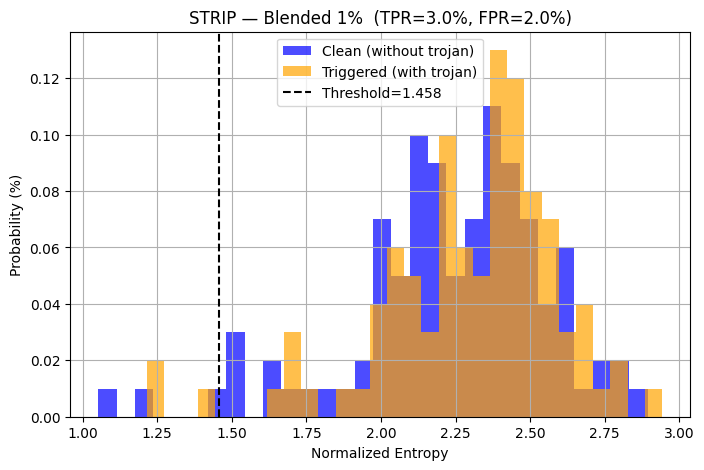

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_1pct_anp_data.npz

────────────────────────────────────────────────────────────
  STRIP — 1% baseline
────────────────────────────────────────────────────────────
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 28.04it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 29.44it/s]



STRIP Results:
  Clean entropy — mean: 0.6257, std: 0.1963
  Threshold (FRR=1%): 0.1690
  Min clean entropy:     0.0398
  Max triggered entropy: 0.4147
  TPR (detection rate):  92.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_1pct_baseline.png


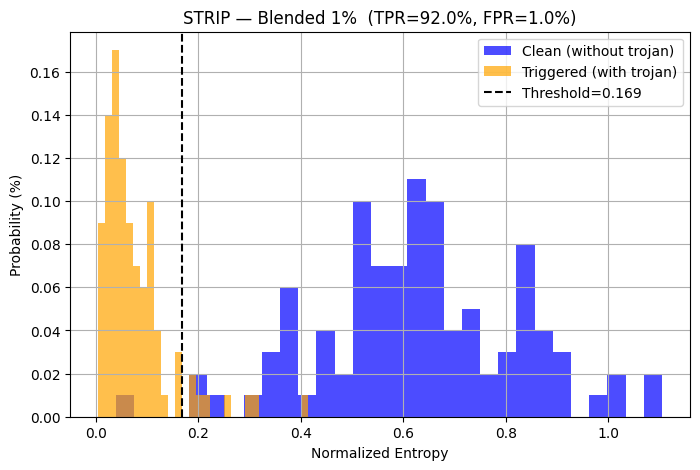

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_1pct_baseline_data.npz

────────────────────────────────────────────────────────────
  STRIP — 1% fine_tune
────────────────────────────────────────────────────────────
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:04<00:00, 22.99it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 27.77it/s]



STRIP Results:
  Clean entropy — mean: 0.6448, std: 0.1766
  Threshold (FRR=1%): 0.2340
  Min clean entropy:     0.0361
  Max triggered entropy: 0.4661
  TPR (detection rate):  88.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_1pct_fine_tune.png


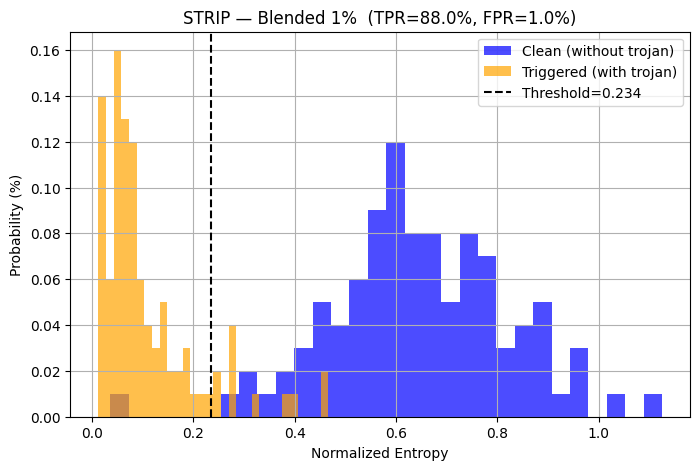

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_1pct_fine_tune_data.npz

────────────────────────────────────────────────────────────
  STRIP — 10% anp
────────────────────────────────────────────────────────────
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 27.93it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:04<00:00, 24.91it/s]



STRIP Results:
  Clean entropy — mean: 2.1452, std: 0.3755
  Threshold (FRR=1%): 1.2716
  Min clean entropy:     0.6423
  Max triggered entropy: 2.8656
  TPR (detection rate):  1.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_10pct_anp.png


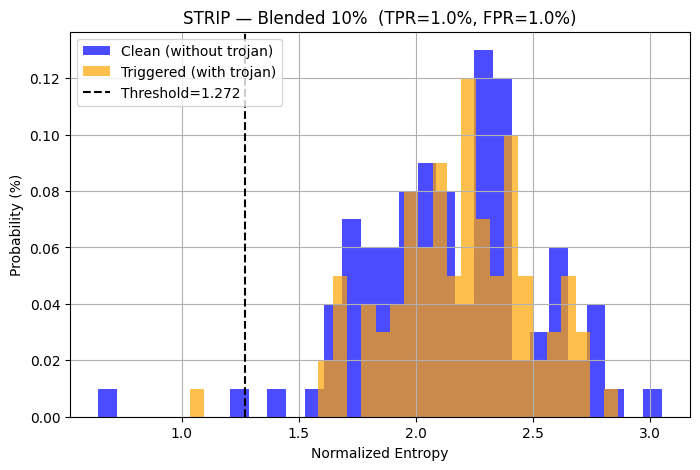

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_10pct_anp_data.npz

────────────────────────────────────────────────────────────
  STRIP — 10% baseline
────────────────────────────────────────────────────────────
  ⚠️  WARNING: STRIP has a known blind spot for the 10% Blended
     baseline. STRIP may report very low/0% TPR despite 100% ASR.
     This is a documented limitation — do NOT interpret low STRIP
     TPR by itself as proof that the backdoor is absent.
     See docs/05_DETECTION_AND_VERIFICATION.md for details.
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 27.87it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 28.42it/s]



STRIP Results:
  Clean entropy — mean: 0.6836, std: 0.1862
  Threshold (FRR=1%): 0.2505
  Min clean entropy:     0.0397
  Max triggered entropy: 0.8371
  TPR (detection rate):  90.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_10pct_baseline.png


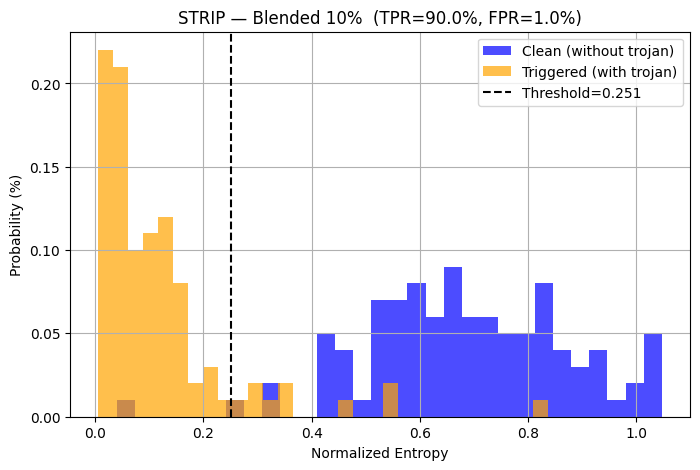

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_10pct_baseline_data.npz

────────────────────────────────────────────────────────────
  STRIP — 10% fine_tune
────────────────────────────────────────────────────────────
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:04<00:00, 24.49it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 28.70it/s]



STRIP Results:
  Clean entropy — mean: 1.0367, std: 0.3164
  Threshold (FRR=1%): 0.3008
  Min clean entropy:     0.0420
  Max triggered entropy: 1.5367
  TPR (detection rate):  34.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_10pct_fine_tune.png


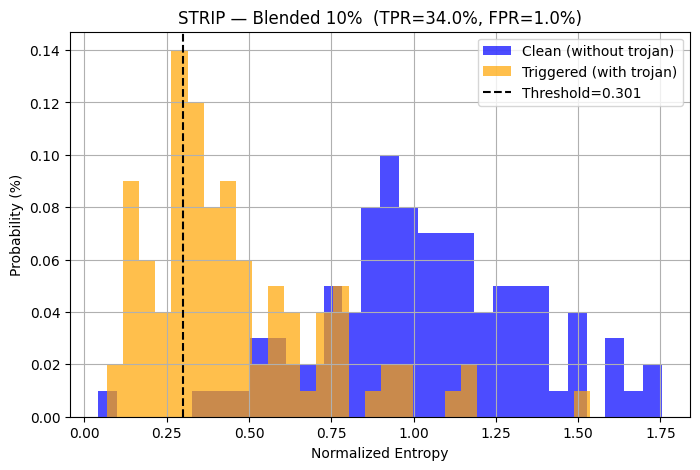

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_10pct_fine_tune_data.npz

────────────────────────────────────────────────────────────
  STRIP — 5% anp
────────────────────────────────────────────────────────────
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 26.02it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:04<00:00, 24.18it/s]



STRIP Results:
  Clean entropy — mean: 2.5074, std: 0.2729
  Threshold (FRR=1%): 1.8724
  Min clean entropy:     1.3645
  Max triggered entropy: 3.0885
  TPR (detection rate):  0.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_5pct_anp.png


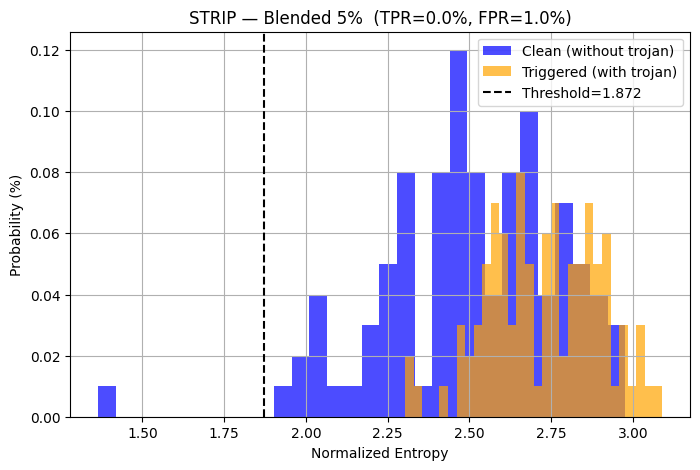

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_5pct_anp_data.npz

────────────────────────────────────────────────────────────
  STRIP — 5% baseline
────────────────────────────────────────────────────────────
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 27.67it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 27.61it/s]



STRIP Results:
  Clean entropy — mean: 0.6877, std: 0.1795
  Threshold (FRR=1%): 0.2700
  Min clean entropy:     0.0764
  Max triggered entropy: 0.5061
  TPR (detection rate):  96.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_5pct_baseline.png


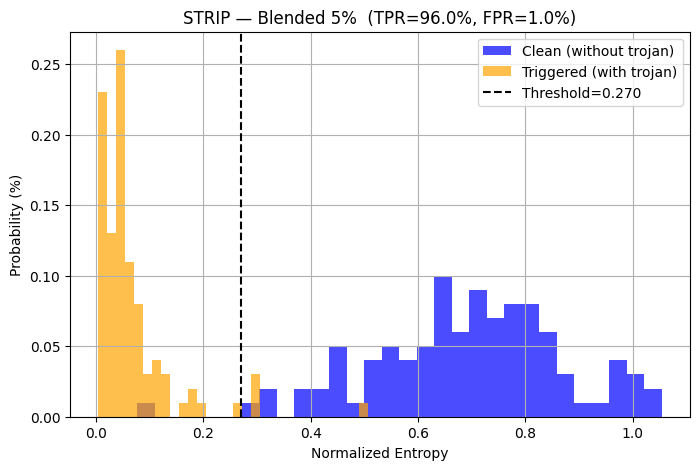

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_5pct_baseline_data.npz

────────────────────────────────────────────────────────────
  STRIP — 5% fine_tune
────────────────────────────────────────────────────────────
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 26.83it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 27.90it/s]



STRIP Results:
  Clean entropy — mean: 0.5699, std: 0.1751
  Threshold (FRR=1%): 0.1624
  Min clean entropy:     0.0587
  Max triggered entropy: 0.4009
  TPR (detection rate):  98.00%
  FPR (false alarms):    2.00%
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_5pct_fine_tune.png


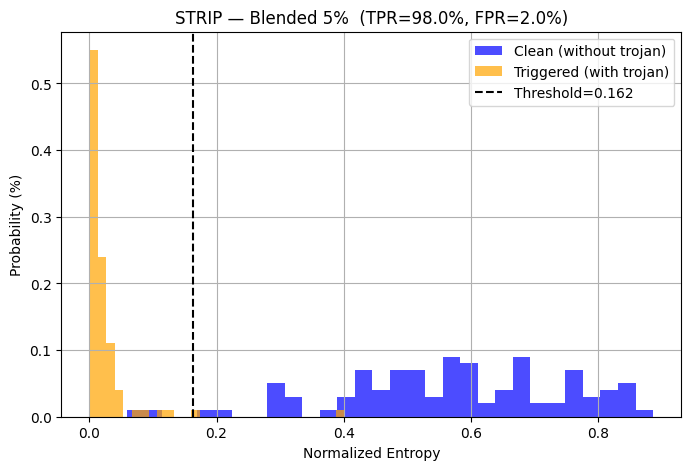

  Saved entropy data: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/strip_5pct_fine_tune_data.npz

STRIP SUMMARY
Poison Rate   Stage              TPR       FPR   Threshold
--------------------------------------------------------
1%            anp              3.00%     2.00%      1.4584
1%            baseline        92.00%     1.00%      0.1690
1%            fine_tune       88.00%     1.00%      0.2340
10%           anp              1.00%     1.00%      1.2716
10%           baseline        90.00%     1.00%      0.2505
10%           fine_tune       34.00%     1.00%      0.3008
5%            anp              0.00%     1.00%      1.8724
5%            baseline        96.00%     1.00%      0.2700
5%            fine_tune       98.00%     2.00%      0.1624

✔ STRIP verification complete.


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# 12.  Post-Defense STRIP Verification
# ══════════════════════════════════════════════════════════════════════════════

from core.detection import run_strip, plot_strip_results

# ── Build asr_test_idx from the existing triggered dataset ────────────────
# This is the same pool of non-target-class test indices used by the ASR loader.
asr_test_idx = np.array(triggered_dataset.indices) if blend_pattern is not None else np.array([])

# ── Trigger function for STRIP (Blended attack) ──────────────────────────
def blended_trigger_fn(img_np):
    """Apply the Blended trigger to a raw image. Used by STRIP."""
    return add_blended_trigger_global(img_np, blend_pattern, CFG["ALPHA_TEST"])

strip_all_results = {}  # key: (pr_label, stage) -> value: strip result dict

print("=" * 70)
print("POST-DEFENSE STRIP VERIFICATION")
print("=" * 70)

if blend_pattern is None or len(asr_test_idx) == 0:
    print("\u26a0\ufe0f  Blend pattern or ASR test indices not available — skipping STRIP.")
else:
    for (pr_label, stage), ckpt_path in sorted(checkpoint_registry.items()):
        pr_suffix = pr_label.replace("%", "").strip()

        print(f"\n{'\u2500'*60}")
        print(f"  STRIP — {pr_label} {stage}")
        print(f"{'\u2500'*60}")

        # Known STRIP blind spot warning for 10% Blended baseline
        if pr_label == "10%" and stage == "baseline":
            print("  \u26a0\ufe0f  WARNING: STRIP has a known blind spot for the 10% Blended")
            print("     baseline. STRIP may report very low/0% TPR despite 100% ASR.")
            print("     This is a documented limitation — do NOT interpret low STRIP")
            print("     TPR by itself as proof that the backdoor is absent.")
            print("     See docs/05_DETECTION_AND_VERIFICATION.md for details.")

        # Load model
        model = load_checkpoint(ckpt_path)

        # Run STRIP
        strip_result = run_strip(
            model=model,
            test_dataset_raw=testset_raw,
            clean_dataset_raw=testset_raw,  # Use test set as clean reference
            device=CFG["DEVICE"],
            transform=transform_test,
            target_class=CFG["TARGET_CLASS"],
            trigger_fn=blended_trigger_fn,
            asr_test_idx=asr_test_idx,
            n_samples=200,
            n_superimpose=50,
            seed=CFG["SEED"],
        )

        strip_all_results[(pr_label, stage)] = strip_result

        # Save plot
        plot_name = f"strip_{pr_suffix}pct_{stage}.png"
        plot_path = os.path.join(CFG["OUTPUT_DIR"], plot_name)
        plot_strip_results(
            strip_result,
            attack_name="Blended",
            poison_rate=float(pr_suffix) / 100.0,
            save_path=plot_path,
        )

        # Save entropy arrays
        npy_name = f"strip_{pr_suffix}pct_{stage}_data.npz"
        npy_path = os.path.join(CFG["OUTPUT_DIR"], npy_name)
        np.savez(npy_path,
                 entropies=strip_result["entropies"],
                 labels_gt=strip_result["labels_gt"])
        print(f"  Saved entropy data: {npy_path}")

        # Clean up
        del model
        torch.cuda.empty_cache()

    # ── STRIP Summary Table ──────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("STRIP SUMMARY")
    print("=" * 70)
    print(f"{'Poison Rate':<12s}  {'Stage':<12s}  {'TPR':>8s}  {'FPR':>8s}  {'Threshold':>10s}")
    print("-" * 56)
    for (pr, stage), res in sorted(strip_all_results.items()):
        print(f"{pr:<12s}  {stage:<12s}  {res['TPR']:>7.2f}%  {res['FPR']:>7.2f}%  {res['threshold']:>10.4f}")

print("\n\u2714 STRIP verification complete.")


## Section 13 — Post-Defense Grad-CAM — Attention Correlation

For the Blended attack (whole-image trigger with no fixed patch), TAR
(Trigger Attention Ratio) based on a bounding box is not meaningful.

Instead, we measure the **Pearson correlation** between:
- Grad-CAM heatmap of a **clean** image
- Grad-CAM heatmap of the **triggered** version of the same image

**Interpretation:** A higher correlation after defense indicates that the
model's attention has become more similar for clean and triggered inputs,
supporting the conclusion that the trigger-driven attention pathway has
been reduced by the defense.

Uses `model.layer4` as the Grad-CAM target layer (standard for ResNet-18).

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# 13.  Post-Defense Grad-CAM — Attention Correlation  (FIXED)
# ══════════════════════════════════════════════════════════════════════════════
#
# Key fix:  Use the model's PREDICTED CLASS as the Grad-CAM target for each
#           image, instead of forcing CFG["TARGET_CLASS"] (airplane / class 0).
#
#           The test images are all non-airplane.  Asking "what makes the model
#           think this is an airplane?" on a horse image produces negligible
#           gradients → all-zero heatmaps.  ANP pruning makes this even worse.
#
#           Using the predicted class guarantees a strong activation signal
#           and meaningful heatmaps for both clean and triggered versions.
# ══════════════════════════════════════════════════════════════════════════════

from scipy.stats import pearsonr
import matplotlib
matplotlib.use("Agg")          # non-interactive backend (safe in Colab / headless)
import matplotlib.pyplot as plt


# ── Grad-CAM implementation (minimal, for ResNet-18) ─────────────────────

def gradcam_heatmap(model, input_tensor, target_layer):
    """Compute Grad-CAM heatmap using the model's *predicted* class.

    Args:
        model:        ResNet-18 model (already in eval mode).
        input_tensor: (1, C, H, W) normalised input tensor on the correct device.
        target_layer: nn.Module — the layer to hook (e.g. model.layer4).

    Returns:
        heatmap:        (h, w) numpy array, normalised to [0, 1].
        predicted_class: int — the class index used for Grad-CAM.
        status:         str — 'ok', or a short reason for invalidity.
    """
    activations = []
    gradients   = []

    def forward_hook(module, inp, out):
        activations.append(out.detach())

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    # Register hooks
    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    try:
        # Ensure gradients are enabled (safety net against upstream no_grad)
        with torch.enable_grad():
            model.zero_grad(set_to_none=True)

            output = model(input_tensor)                    # (1, num_classes)
            predicted_class = output.argmax(dim=1).item()

            # Backward for the predicted class
            one_hot = torch.zeros_like(output)
            one_hot[0, predicted_class] = 1.0
            output.backward(gradient=one_hot, retain_graph=False)

        # Validate that hooks captured data
        if len(activations) == 0:
            return None, predicted_class, "no_activations"
        if len(gradients) == 0:
            return None, predicted_class, "no_gradients"

        # Grad-CAM computation
        grads = gradients[0]                                # (1, C, h, w)
        acts  = activations[0]                              # (1, C, h, w)
        weights = grads.mean(dim=(2, 3), keepdim=True)      # GAP over spatial dims
        cam = (weights * acts).sum(dim=1, keepdim=True)     # weighted combination
        cam = torch.relu(cam)                               # ReLU
        cam = cam.squeeze().cpu().numpy()                   # (h, w)

        # ── Validity checks ──────────────────────────────────────────────
        if np.isnan(cam).any():
            return None, predicted_class, "nan"
        if np.isinf(cam).any():
            return None, predicted_class, "inf"
        if cam.max() == 0:
            return None, predicted_class, "allzero"
        if cam.std() < 1e-8:
            return None, predicted_class, "constant"

        # Normalise to [0, 1]
        cam = cam / cam.max()
        return cam, predicted_class, "ok"

    finally:
        # Always remove hooks — never accumulate across calls
        fh.remove()
        bh.remove()
        model.zero_grad(set_to_none=True)


# ── Heatmap validity check (used before Pearson correlation) ─────────────

def _check_heatmap_valid(hm, label):
    """Return (is_valid: bool, reason: str) for a heatmap numpy array."""
    if hm is None:
        return False, f"{label}_none"
    if np.isnan(hm).any():
        return False, f"{label}_nan"
    if np.isinf(hm).any():
        return False, f"{label}_inf"
    if hm.max() == 0:
        return False, f"{label}_allzero"
    if hm.flatten().std() < 1e-8:
        return False, f"{label}_constant"
    return True, "ok"


# ── Select fixed test samples for Grad-CAM ──────────────────────────────
GRADCAM_N_SAMPLES = 50

# Use non-target-class test images (same pool concept as ASR)
rng_gc = np.random.RandomState(CFG["SEED"])
non_target_test_indices = [
    i for i in range(len(testset_raw))
    if testset_raw.targets[i] != CFG["TARGET_CLASS"]
]
gradcam_sample_indices = rng_gc.choice(
    non_target_test_indices, GRADCAM_N_SAMPLES, replace=False
)

# Indices to use for diagnostic visualizations (first 4 of the 50)
VIS_INDICES = gradcam_sample_indices[:4]

CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

print("=" * 70)
print("POST-DEFENSE GRAD-CAM — ATTENTION CORRELATION  (FIXED)")
print(f"  Target layer  : model.layer4")
print(f"  Target class  : model's predicted class (per-image)")
print(f"  Samples       : {GRADCAM_N_SAMPLES}")
print(f"  Metric        : Pearson correlation (clean vs triggered heatmap)")
print(f"  Vis. samples  : {len(VIS_INDICES)} per baseline + ANP checkpoint")
print("=" * 70)

gradcam_all_results = {}   # key: (pr_label, stage) -> value: dict

if blend_pattern is None:
    print("\u26a0\ufe0f  Blend pattern not available — skipping Grad-CAM.")
else:
    for (pr_label, stage), ckpt_path in sorted(checkpoint_registry.items()):
        pr_suffix = pr_label.replace("%", "").strip()

        print(f"\n{'\u2500'*60}")
        print(f"  Grad-CAM — {pr_label} {stage}")
        print(f"{'\u2500'*60}")

        # Load model
        model = load_checkpoint(ckpt_path)
        model.eval()

        # Invalidity counters
        inv_reasons = {}

        correlations = []

        # Storage for visualization (only for baseline & ANP)
        vis_data = []   # list of dicts for VIS_INDICES

        for sample_idx in gradcam_sample_indices:
            img_pil, gt_label = testset_raw[sample_idx]
            img_np  = np.array(img_pil)

            # ── Clean image ──────────────────────────────────────────────
            img_clean_tensor = transform_test(img_pil).unsqueeze(0).to(CFG["DEVICE"])

            # ── Triggered image ──────────────────────────────────────────
            img_trig_np  = add_blended_trigger_global(img_np, blend_pattern, CFG["ALPHA_TEST"])
            img_trig_pil = Image.fromarray(img_trig_np)
            img_trig_tensor = transform_test(img_trig_pil).unsqueeze(0).to(CFG["DEVICE"])

            # ── Grad-CAM (predicted class for each image) ────────────────
            hm_clean, pred_clean, status_clean = gradcam_heatmap(
                model, img_clean_tensor, model.layer4
            )
            hm_trig, pred_trig, status_trig = gradcam_heatmap(
                model, img_trig_tensor, model.layer4
            )

            # ── Validity checks ──────────────────────────────────────────
            clean_ok, clean_reason = _check_heatmap_valid(hm_clean, "clean")
            trig_ok,  trig_reason  = _check_heatmap_valid(hm_trig,  "triggered")

            if not clean_ok:
                reason = clean_reason if status_clean == "ok" else f"clean_{status_clean}"
                inv_reasons[reason] = inv_reasons.get(reason, 0) + 1
                # Collect vis data even if invalid (for debugging)
                if sample_idx in VIS_INDICES and stage in ("baseline", "anp"):
                    vis_data.append({
                        "sample_idx": sample_idx, "gt_label": gt_label,
                        "img_clean": img_np, "img_trig": img_trig_np,
                        "hm_clean": hm_clean, "hm_trig": hm_trig,
                        "pred_clean": pred_clean, "pred_trig": pred_trig,
                        "valid": False, "reason": reason,
                    })
                continue

            if not trig_ok:
                reason = trig_reason if status_trig == "ok" else f"triggered_{status_trig}"
                inv_reasons[reason] = inv_reasons.get(reason, 0) + 1
                if sample_idx in VIS_INDICES and stage in ("baseline", "anp"):
                    vis_data.append({
                        "sample_idx": sample_idx, "gt_label": gt_label,
                        "img_clean": img_np, "img_trig": img_trig_np,
                        "hm_clean": hm_clean, "hm_trig": hm_trig,
                        "pred_clean": pred_clean, "pred_trig": pred_trig,
                        "valid": False, "reason": reason,
                    })
                continue

            # ── Pearson correlation ───────────────────────────────────────
            r, _ = pearsonr(hm_clean.flatten(), hm_trig.flatten())

            if np.isnan(r) or np.isinf(r):
                inv_reasons["pearson_nan_or_inf"] = inv_reasons.get("pearson_nan_or_inf", 0) + 1
                if sample_idx in VIS_INDICES and stage in ("baseline", "anp"):
                    vis_data.append({
                        "sample_idx": sample_idx, "gt_label": gt_label,
                        "img_clean": img_np, "img_trig": img_trig_np,
                        "hm_clean": hm_clean, "hm_trig": hm_trig,
                        "pred_clean": pred_clean, "pred_trig": pred_trig,
                        "valid": False, "reason": "pearson_nan_or_inf",
                    })
                continue

            correlations.append(r)

            # Collect visualisation data for baseline & ANP
            if sample_idx in VIS_INDICES and stage in ("baseline", "anp"):
                vis_data.append({
                    "sample_idx": sample_idx, "gt_label": gt_label,
                    "img_clean": img_np, "img_trig": img_trig_np,
                    "hm_clean": hm_clean, "hm_trig": hm_trig,
                    "pred_clean": pred_clean, "pred_trig": pred_trig,
                    "valid": True, "reason": "ok", "r": r,
                })

        # ── Aggregate results ────────────────────────────────────────────
        n_valid   = len(correlations)
        n_invalid = GRADCAM_N_SAMPLES - n_valid

        if n_valid > 0:
            mean_corr = float(np.mean(correlations))
            std_corr  = float(np.std(correlations))
        else:
            mean_corr = None   # N/A
            std_corr  = None

        gradcam_all_results[(pr_label, stage)] = {
            "mean_pearson_r": round(mean_corr, 4) if mean_corr is not None else None,
            "std_pearson_r":  round(std_corr, 4)  if std_corr  is not None else None,
            "n_valid":        n_valid,
            "n_invalid":      n_invalid,
        }

        # ── Print results ────────────────────────────────────────────────
        if mean_corr is not None:
            print(f"    Mean Pearson r : {mean_corr:.4f} \u00b1 {std_corr:.4f}")
        else:
            print(f"    Mean Pearson r : N/A  (no valid samples)")
        print(f"    Valid samples  : {n_valid} / {GRADCAM_N_SAMPLES}")
        print(f"    Invalid samples: {n_invalid} / {GRADCAM_N_SAMPLES}")

        if inv_reasons:
            print(f"    Invalidity breakdown:")
            for reason, count in sorted(inv_reasons.items()):
                print(f"      {reason:30s} : {count}")
        else:
            print(f"    (no invalid samples)")

        # ── Diagnostic visualisation (baseline & ANP) ────────────────────
        if vis_data and stage in ("baseline", "anp"):
            n_vis = len(vis_data)
            fig, axes = plt.subplots(n_vis, 4, figsize=(16, 4 * n_vis))
            if n_vis == 1:
                axes = axes[np.newaxis, :]   # ensure 2D

            fig.suptitle(
                f"Grad-CAM Diagnostic — {pr_label} {stage}\n"
                f"(Valid: {n_valid}/{GRADCAM_N_SAMPLES})",
                fontsize=14, fontweight="bold",
            )

            for row_idx, vd in enumerate(vis_data):
                # Clean image
                axes[row_idx, 0].imshow(vd["img_clean"])
                pred_name_c = CIFAR_CLASSES[vd["pred_clean"]] if vd["pred_clean"] is not None else "?"
                gt_name     = CIFAR_CLASSES[vd["gt_label"]]
                axes[row_idx, 0].set_title(
                    f"Clean  (gt={gt_name}, pred={pred_name_c})", fontsize=9
                )
                axes[row_idx, 0].axis("off")

                # Clean Grad-CAM
                if vd["hm_clean"] is not None:
                    axes[row_idx, 1].imshow(vd["hm_clean"], cmap="jet", vmin=0, vmax=1)
                else:
                    axes[row_idx, 1].text(0.5, 0.5, "INVALID", ha="center", va="center",
                                          fontsize=12, color="red", transform=axes[row_idx, 1].transAxes)
                axes[row_idx, 1].set_title(f"Clean Grad-CAM", fontsize=9)
                axes[row_idx, 1].axis("off")

                # Triggered image
                axes[row_idx, 2].imshow(vd["img_trig"])
                pred_name_t = CIFAR_CLASSES[vd["pred_trig"]] if vd["pred_trig"] is not None else "?"
                axes[row_idx, 2].set_title(
                    f"Triggered  (pred={pred_name_t})", fontsize=9
                )
                axes[row_idx, 2].axis("off")

                # Triggered Grad-CAM
                if vd["hm_trig"] is not None:
                    axes[row_idx, 3].imshow(vd["hm_trig"], cmap="jet", vmin=0, vmax=1)
                else:
                    axes[row_idx, 3].text(0.5, 0.5, "INVALID", ha="center", va="center",
                                          fontsize=12, color="red", transform=axes[row_idx, 3].transAxes)
                r_str = f"r={vd['r']:.3f}" if vd.get("r") is not None else vd["reason"]
                axes[row_idx, 3].set_title(f"Triggered Grad-CAM  ({r_str})", fontsize=9)
                axes[row_idx, 3].axis("off")

            plt.tight_layout(rect=[0, 0, 1, 0.96])

            vis_name = f"gradcam_vis_{pr_suffix}pct_{stage}.png"
            vis_path = os.path.join(CFG["OUTPUT_DIR"], vis_name)
            os.makedirs(CFG["OUTPUT_DIR"], exist_ok=True)
            plt.savefig(vis_path, dpi=120, bbox_inches="tight")
            plt.close(fig)
            print(f"    Saved diagnostic figure: {vis_name}")

        # Clean up
        del model
        torch.cuda.empty_cache()

    # ── Grad-CAM Summary Table ───────────────────────────────────────────
    print("\n" + "=" * 70)
    print("GRAD-CAM CORRELATION SUMMARY")
    print("=" * 70)
    print(f"{'Poison Rate':<12s}  {'Stage':<12s}  {'Mean r':>8s}  {'Std':>8s}  "
          f"{'Valid':>5s}  {'Invalid':>7s}")
    print("-" * 60)
    for (pr, stage), res in sorted(gradcam_all_results.items()):
        mr = f"{res['mean_pearson_r']:>8.4f}" if res["mean_pearson_r"] is not None else "     N/A"
        sr = f"{res['std_pearson_r']:>8.4f}"  if res["std_pearson_r"]  is not None else "     N/A"
        print(f"{pr:<12s}  {stage:<12s}  {mr}  {sr}  "
              f"{res['n_valid']:>5d}  {res['n_invalid']:>7d}")

print("\n\u2714 Grad-CAM verification complete.")


POST-DEFENSE GRAD-CAM — ATTENTION CORRELATION  (FIXED)
  Target layer  : model.layer4
  Target class  : model's predicted class (per-image)
  Samples       : 50
  Metric        : Pearson correlation (clean vs triggered heatmap)
  Vis. samples  : 4 per baseline + ANP checkpoint

────────────────────────────────────────────────────────────
  Grad-CAM — 1% anp
────────────────────────────────────────────────────────────
    Mean Pearson r : 0.7515 ± 0.3222
    Valid samples  : 50 / 50
    Invalid samples: 0 / 50
    (no invalid samples)
    Saved diagnostic figure: gradcam_vis_1pct_anp.png

────────────────────────────────────────────────────────────
  Grad-CAM — 1% baseline
────────────────────────────────────────────────────────────
    Mean Pearson r : 0.8068 ± 0.1194
    Valid samples  : 50 / 50
    Invalid samples: 0 / 50
    (no invalid samples)
    Saved diagnostic figure: gradcam_vis_1pct_baseline.png

────────────────────────────────────────────────────────────
  Grad-CAM — 1% fi

## Section 14 — Combined Verification Table

Merge STRIP and Grad-CAM results into a single comparison table.
Save as `blended_verification_results.csv`.

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# 14.  Combined Verification Table
# ══════════════════════════════════════════════════════════════════════════════

verif_rows = []

# Collect all unique (pr_label, stage) keys
all_keys = sorted(set(list(strip_all_results.keys()) + list(gradcam_all_results.keys())))

for (pr_label, stage) in all_keys:
    row = {
        "Poison Rate": pr_label,
        "Stage":       stage,
    }

    # STRIP columns (unchanged)
    if (pr_label, stage) in strip_all_results:
        sr = strip_all_results[(pr_label, stage)]
        row["STRIP TPR"]       = sr["TPR"]
        row["STRIP FPR"]       = sr["FPR"]
        row["STRIP Threshold"] = sr["threshold"]
    else:
        row["STRIP TPR"]       = None
        row["STRIP FPR"]       = None
        row["STRIP Threshold"] = None

    # Grad-CAM columns (updated: includes Valid N, Invalid N, handles N/A)
    if (pr_label, stage) in gradcam_all_results:
        gc = gradcam_all_results[(pr_label, stage)]
        row["GradCAM Mean r"]   = gc["mean_pearson_r"] if gc["mean_pearson_r"] is not None else "N/A"
        row["GradCAM Std"]      = gc["std_pearson_r"]  if gc["std_pearson_r"]  is not None else "N/A"
        row["GradCAM Valid N"]  = gc["n_valid"]
        row["GradCAM Invalid N"] = gc["n_invalid"]
    else:
        row["GradCAM Mean r"]    = None
        row["GradCAM Std"]       = None
        row["GradCAM Valid N"]   = None
        row["GradCAM Invalid N"] = None

    verif_rows.append(row)

df_verif = pd.DataFrame(verif_rows)

# Save
os.makedirs(CFG["OUTPUT_DIR"], exist_ok=True)
verif_csv_path = os.path.join(CFG["OUTPUT_DIR"], "blended_verification_results.csv")
df_verif.to_csv(verif_csv_path, index=False)

print("=" * 70)
print("COMBINED VERIFICATION TABLE")
print("=" * 70)
print()
print(df_verif.to_string(index=False))
print(f"\nSaved to: {verif_csv_path}")
print("\n\u2714 Verification table complete.")


COMBINED VERIFICATION TABLE

Poison Rate     Stage  STRIP TPR  STRIP FPR  STRIP Threshold  GradCAM Mean r  GradCAM Std  GradCAM Valid N  GradCAM Invalid N
         1%       anp        3.0        2.0           1.4584          0.7515       0.3222               50                  0
         1%  baseline       92.0        1.0           0.1690          0.8068       0.1194               50                  0
         1% fine_tune       88.0        1.0           0.2340          0.8105       0.1132               50                  0
        10%       anp        1.0        1.0           1.2716          0.8048       0.2819               50                  0
        10%  baseline       90.0        1.0           0.2505          0.6262       0.1676               50                  0
        10% fine_tune       34.0        1.0           0.3008          0.5314       0.2891               50                  0
         5%       anp        0.0        1.0           1.8724          0.6040       0.3407

## Section 15 — Results Table

Compile all results into a single comparison table and save as CSV.

In [26]:
# ── 15.  Build results DataFrame ─────────────────────────────────────────

rows = []

for pr_label in CFG["CHECKPOINTS"].keys():
    bl = baseline_results[pr_label]

    # Fine-Tuning row (from Section 9, if available)
    if pr_label in ft_results:
        ft = ft_results[pr_label]
        rows.append({
            "Poison Rate":  pr_label,
            "Defense":      "Fine-Tuning",
            "CA Before":    round(bl["CA"]  * 100, 2),
            "ASR Before":   round(bl["ASR"] * 100, 2) if bl["ASR"] is not None else None,
            "CA After":     round(ft["CA"]  * 100, 2),
            "ASR After":    round(ft["ASR"] * 100, 2) if ft["ASR"] is not None else None,
            "Time (s)":     ft.get("time_sec"),
        })

    # ANP row (from Section 10, if available for this rate)
    if pr_label in anp_results:
        anp = anp_results[pr_label]
        anp_m = anp["after_anp"]
        best_t = anp["best_threshold"]

        rows.append({
            "Poison Rate":  pr_label,
            "Defense":      f"ANP (t={best_t:.2f})" if best_t is not None else "ANP",
            "CA Before":    round(bl["CA"]  * 100, 2),
            "ASR Before":   round(bl["ASR"] * 100, 2) if bl["ASR"] is not None else None,
            "CA After":     round(anp_m["CA"]  * 100, 2),
            "ASR After":    round(anp_m["ASR"] * 100, 2) if anp_m["ASR"] is not None else None,
            "Time (s)":     anp.get("time_mask_opt"),
        })

df_results = pd.DataFrame(rows)

print("=" * 70)
print("DEFENSE RESULTS — BLENDED ATTACK")
print("=" * 70)
print()
print(df_results.to_string(index=False))
print()

# ── Compute Δ columns for analysis ───────────────────────────────────────────
if df_results["ASR Before"].notna().any():
    df_results["CA Drop"]  = df_results["CA Before"]  - df_results["CA After"]
    df_results["ASR Drop"] = df_results["ASR Before"] - df_results["ASR After"]
    print("With deltas:")
    print(df_results.to_string(index=False))

DEFENSE RESULTS — BLENDED ATTACK

Poison Rate     Defense  CA Before  ASR Before  CA After  ASR After  Time (s)
         1% Fine-Tuning      94.39       99.98     93.83      99.99      32.7
         1%         ANP      94.39       99.98     90.14       0.22       0.0
         5% Fine-Tuning      94.33      100.00     93.63     100.00      34.4
         5%         ANP      94.33      100.00     90.39       2.69       0.0
        10% Fine-Tuning      93.88      100.00     93.65     100.00      36.8
        10%         ANP      93.88      100.00     92.07       0.04       0.0

With deltas:
Poison Rate     Defense  CA Before  ASR Before  CA After  ASR After  Time (s)  CA Drop  ASR Drop
         1% Fine-Tuning      94.39       99.98     93.83      99.99      32.7     0.56     -0.01
         1%         ANP      94.39       99.98     90.14       0.22       0.0     4.25     99.76
         5% Fine-Tuning      94.33      100.00     93.63     100.00      34.4     0.70      0.00
         5%       

## Section 16 — Save Results

Save the results CSV to Google Drive and print a final readable summary.

In [31]:
# ── 16.  Save CSV and print summary ──────────────────────────────────────

os.makedirs(CFG["OUTPUT_DIR"], exist_ok=True)
csv_path = os.path.join(CFG["OUTPUT_DIR"], "blended_defense_results.csv")
df_results.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")

# ── Final readable summary ───────────────────────────────────────────────
print("\n" + "=" * 70)
print("STAGE E — DEFENSE SUMMARY (Blended Attack)")
print("=" * 70)
print(f"\nDefenses applied:")
print(f"  1. Fine-Tuning (baseline defense)")
print(f"  2. ANP — Adversarial Neuron Pruning (Liu et al., NeurIPS 2021)")

print(f"\nConfiguration:")
print(f"  Fine-Tuning:")
print(f"    Optimizer           : {CFG['OPTIMIZER']}")
print(f"    Learning rate       : {CFG['FT_LR']}")
print(f"    Max epochs          : {CFG['FT_EPOCHS']}")
print(f"    Validation split    : {'Enabled' if CFG['USE_VALIDATION'] else 'Disabled'}")

print(f"  ANP:")
print(f"    Reference           : Official ANP (csdongxian/ANP_backdoor)")
print(f"    eps                 : {CFG['ANP_EPS']}")
print(f"    steps               : {CFG['ANP_STEPS']}")
print(f"    alpha               : {CFG['ANP_ALPHA']}")
print(f"    lr                  : {CFG['ANP_LR']}")
print(f"    iterations          : {CFG['ANP_NB_ITER']}")
print(f"    pruning method      : {CFG['PRUNING_BY']}")
print(f"    pruning max         : {CFG['PRUNING_MAX']}")
print(f"    pruning step        : {CFG['PRUNING_STEP']}")
print(f"    max CA drop budget  : {CFG['MAX_CA_DROP']}pp")

print(f"\n  Seed                : {CFG['SEED']}")
print(f"  ASR evaluation      : {'Enabled' if asr_test_loader is not None else 'Disabled'}")

# ── ANP-specific summary ──────────────────────────────────────────────────
for pr_label, anp in anp_results.items():
    bl = anp['baseline']
    after = anp['after_anp']
    best_t = anp['best_threshold']

    # Fix: Handle None threshold gracefully
    t_str = f"{best_t:.2f}" if best_t is not None else "N/A"

    print(f"\n  ANP Results ({pr_label}):")
    print(f"    Selected threshold  : {t_str}")
    print(f"    Neurons pruned      : {anp['n_pruned']} / {anp['n_total']}")
    print(f"    Mask opt time       : {anp['time_mask_opt']}s")
    print(f"    {'Stage':<25s}  {'CA':>8s}  {'ASR':>8s}")
    print(f"    {'-'*25}  {'-'*8}  {'-'*8}")

    # Update stage names in print loop
    stages = [("Baseline", bl), (f"ANP (t={t_str})", after)]
    for stage_name, m in stages:
        ca_s  = f"{m['CA']*100:.2f}%"
        asr_s = f"{m['ASR']*100:.2f}%" if m['ASR'] is not None else "N/A"
        print(f"    {stage_name:<25s}  {ca_s:>8s}  {asr_s:>8s}")

    if bl['ASR'] is not None and after['ASR'] is not None:
        ca_drop = bl['CA']*100 - after['CA']*100
        asr_drop = bl['ASR']*100 - after['ASR']*100
        print(f"\n    CA Drop  : {ca_drop:.2f}pp")
        print(f"    ASR Drop : {asr_drop:.2f}pp")

print(f"\nDefended checkpoints saved to:")
print(f"  {CFG['OUTPUT_DIR']}")

# List saved files
if os.path.isdir(CFG["OUTPUT_DIR"]):
    for f in sorted(os.listdir(CFG["OUTPUT_DIR"])):
        fpath = os.path.join(CFG["OUTPUT_DIR"], f)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"    {f:50s} ({size_mb:.1f} MB)")

print(f"\nResults CSV: {csv_path}")
print("\n" + "=" * 70)
print("Stage E complete.")
print("=" * 70)

Results saved to: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/blended_defense_results.csv

STAGE E — DEFENSE SUMMARY (Blended Attack)

Defenses applied:
  1. Fine-Tuning (baseline defense)
  2. ANP — Adversarial Neuron Pruning (Liu et al., NeurIPS 2021)

Configuration:
  Fine-Tuning:
    Optimizer           : SGD
    Learning rate       : 0.0001
    Max epochs          : 15
    Validation split    : Disabled
  ANP:
    Reference           : Official ANP (csdongxian/ANP_backdoor)
    eps                 : 0.4
    steps               : 1
    alpha               : 0.2
    lr                  : 0.2
    iterations          : 2000
    pruning method      : threshold
    pruning max         : 0.9
    pruning step        : 0.05
    max CA drop budget  : 5.0pp

  Seed                : 2027
  ASR evaluation      : Enabled

  ANP Results (1%):
    Selected threshold  : N/A
    Neurons pruned      : 0 / 0
    Mask opt time       : 0.0s
    Stage                            CA       ASR

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# Grad-CAM Visual Comparison — Blended Attack
# Clean vs Triggered, Before vs After ANP
# ══════════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch


CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


def generate_blended_gradcam_figure(
    pr_label,
    sample_indices,
    save_name=None
):
    """
    Generate a figure similar to the reference image.

    Columns:
        1. Clean image
        2. Clean BEFORE Grad-CAM
        3. Clean AFTER ANP Grad-CAM
        4. Triggered image
        5. Triggered BEFORE Grad-CAM
        6. Triggered AFTER ANP Grad-CAM
    """

    # ---------------------------------------------------------
    # Find baseline and ANP checkpoints
    # ---------------------------------------------------------

    baseline_key = (pr_label, "baseline")
    anp_key = (pr_label, "anp")

    if baseline_key not in checkpoint_registry:
        print(f"❌ Baseline checkpoint not found for {pr_label}")
        return

    if anp_key not in checkpoint_registry:
        print(f"❌ ANP checkpoint not found for {pr_label}")
        return

    baseline_path = checkpoint_registry[baseline_key]
    anp_path = checkpoint_registry[anp_key]

    print(f"Loading baseline: {os.path.basename(baseline_path)}")
    model_before = load_checkpoint(baseline_path)
    model_before.eval()

    print(f"Loading ANP:      {os.path.basename(anp_path)}")
    model_after = load_checkpoint(anp_path)
    model_after.eval()

    device = CFG["DEVICE"]

    # ---------------------------------------------------------
    # Process samples
    # ---------------------------------------------------------

    for sample_idx in sample_indices:

        img_pil, gt_label = testset_raw[sample_idx]
        img_np = np.array(img_pil)

        # -----------------------------------------------------
        # Create Blended triggered image
        # -----------------------------------------------------

        triggered_np = add_blended_trigger_global(
            img_np,
            blend_pattern,
            CFG["ALPHA_TEST"]
        )

        triggered_pil = Image.fromarray(triggered_np)

        # -----------------------------------------------------
        # Convert to model inputs
        # -----------------------------------------------------

        clean_tensor = (
            transform_test(img_pil)
            .unsqueeze(0)
            .to(device)
        )

        triggered_tensor = (
            transform_test(triggered_pil)
            .unsqueeze(0)
            .to(device)
        )

        # =====================================================
        # BASELINE MODEL
        # =====================================================

        # Clean BEFORE
        hm_clean_before, pred_clean_before, status = gradcam_heatmap(
            model_before,
            clean_tensor,
            model_before.layer4
        )

        # Triggered BEFORE
        hm_triggered_before, pred_triggered_before, status = gradcam_heatmap(
            model_before,
            triggered_tensor,
            model_before.layer4
        )

        # =====================================================
        # ANP MODEL
        # =====================================================

        # Clean AFTER
        hm_clean_after, pred_clean_after, status = gradcam_heatmap(
            model_after,
            clean_tensor,
            model_after.layer4
        )

        # Triggered AFTER
        hm_triggered_after, pred_triggered_after, status = gradcam_heatmap(
            model_after,
            triggered_tensor,
            model_after.layer4
        )

        # -----------------------------------------------------
        # Pearson correlations
        # -----------------------------------------------------

        def safe_pearson(a, b):

            if a is None or b is None:
                return None

            a = a.flatten()
            b = b.flatten()

            if np.std(a) < 1e-8 or np.std(b) < 1e-8:
                return None

            from scipy.stats import pearsonr

            r, _ = pearsonr(a, b)

            if np.isnan(r) or np.isinf(r):
                return None

            return float(r)

        r_before = safe_pearson(
            hm_clean_before,
            hm_triggered_before
        )

        r_after = safe_pearson(
            hm_clean_after,
            hm_triggered_after
        )

        # -----------------------------------------------------
        # Class names
        # -----------------------------------------------------

        gt_name = CIFAR_CLASSES[gt_label]

        clean_before_name = CIFAR_CLASSES[pred_clean_before]
        triggered_before_name = CIFAR_CLASSES[pred_triggered_before]

        clean_after_name = CIFAR_CLASSES[pred_clean_after]
        triggered_after_name = CIFAR_CLASSES[pred_triggered_after]

        # -----------------------------------------------------
        # Create figure
        # -----------------------------------------------------

        fig, axes = plt.subplots(
            1,
            6,
            figsize=(18, 4)
        )

        fig.suptitle(
            f"Blended Attack — {pr_label} Poison Rate",
            fontsize=15,
            fontweight="bold"
        )

        # =====================================================
        # 1 — CLEAN IMAGE
        # =====================================================

        axes[0].imshow(img_np)

        axes[0].set_title(
            f"Clean\nGT: {gt_name}",
            fontsize=10
        )

        axes[0].axis("off")

        # =====================================================
        # 2 — CLEAN BEFORE
        # =====================================================

        axes[1].imshow(img_np)

        if hm_clean_before is not None:
            axes[1].imshow(
                hm_clean_before,
                cmap="jet",
                alpha=0.45,
                vmin=0,
                vmax=1
            )

        axes[1].set_title(
            f"Clean BEFORE\nPred: {clean_before_name}",
            fontsize=10
        )

        axes[1].axis("off")

        # =====================================================
        # 3 — CLEAN AFTER ANP
        # =====================================================

        axes[2].imshow(img_np)

        if hm_clean_after is not None:
            axes[2].imshow(
                hm_clean_after,
                cmap="jet",
                alpha=0.45,
                vmin=0,
                vmax=1
            )

        axes[2].set_title(
            f"Clean AFTER ANP\nPred: {clean_after_name}",
            fontsize=10
        )

        axes[2].axis("off")

        # =====================================================
        # 4 — TRIGGERED IMAGE
        # =====================================================

        axes[3].imshow(triggered_np)

        axes[3].set_title(
            f"Triggered\nPred: {triggered_before_name}",
            fontsize=10
        )

        axes[3].axis("off")

        # =====================================================
        # 5 — TRIGGERED BEFORE
        # =====================================================

        axes[4].imshow(triggered_np)

        if hm_triggered_before is not None:
            axes[4].imshow(
                hm_triggered_before,
                cmap="jet",
                alpha=0.45,
                vmin=0,
                vmax=1
            )

        r_before_text = (
            f"r = {r_before:.3f}"
            if r_before is not None
            else "r = N/A"
        )

        axes[4].set_title(
            f"Triggered BEFORE\n{r_before_text}",
            fontsize=10
        )

        axes[4].axis("off")

        # =====================================================
        # 6 — TRIGGERED AFTER ANP
        # =====================================================

        axes[5].imshow(triggered_np)

        if hm_triggered_after is not None:
            axes[5].imshow(
                hm_triggered_after,
                cmap="jet",
                alpha=0.45,
                vmin=0,
                vmax=1
            )

        r_after_text = (
            f"r = {r_after:.3f}"
            if r_after is not None
            else "r = N/A"
        )

        axes[5].set_title(
            f"Triggered AFTER ANP\n{r_after_text}",
            fontsize=10
        )

        axes[5].axis("off")

        # -----------------------------------------------------
        # Layout
        # -----------------------------------------------------

        plt.tight_layout(rect=[0, 0, 1, 0.92])

        # -----------------------------------------------------
        # Save
        # -----------------------------------------------------

        if save_name is None:
            suffix = pr_label.replace("%", "")
            save_name = f"blended_gradcam_comparison_{suffix}pct.png"

        save_path = os.path.join(
            CFG["OUTPUT_DIR"],
            save_name
        )

        plt.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")

        # Only generate the first requested sample
        # so the cell produces one clean comparison figure.
        break

    # ---------------------------------------------------------
    # Cleanup
    # ---------------------------------------------------------

    del model_before
    del model_after

    torch.cuda.empty_cache()

In [33]:
generate_blended_gradcam_figure(
    pr_label="10%",
    sample_indices=gradcam_sample_indices[:4]
)

Loading baseline: resnet18_blended_pr10.pth
Loading ANP:      resnet18_blended_pr10_anp.pth
Saved: /content/drive/MyDrive/ps-capstone1/defended_checkpoints/blended_gradcam_comparison_10pct.png


Selected test samples: [9167, 9083, 1860]

Grad-CAM — Blended 1% ANP
Loading ANP checkpoint...

Grad-CAM — Blended 5% ANP
Loading ANP checkpoint...

Grad-CAM — Blended 10% ANP
Loading ANP checkpoint...


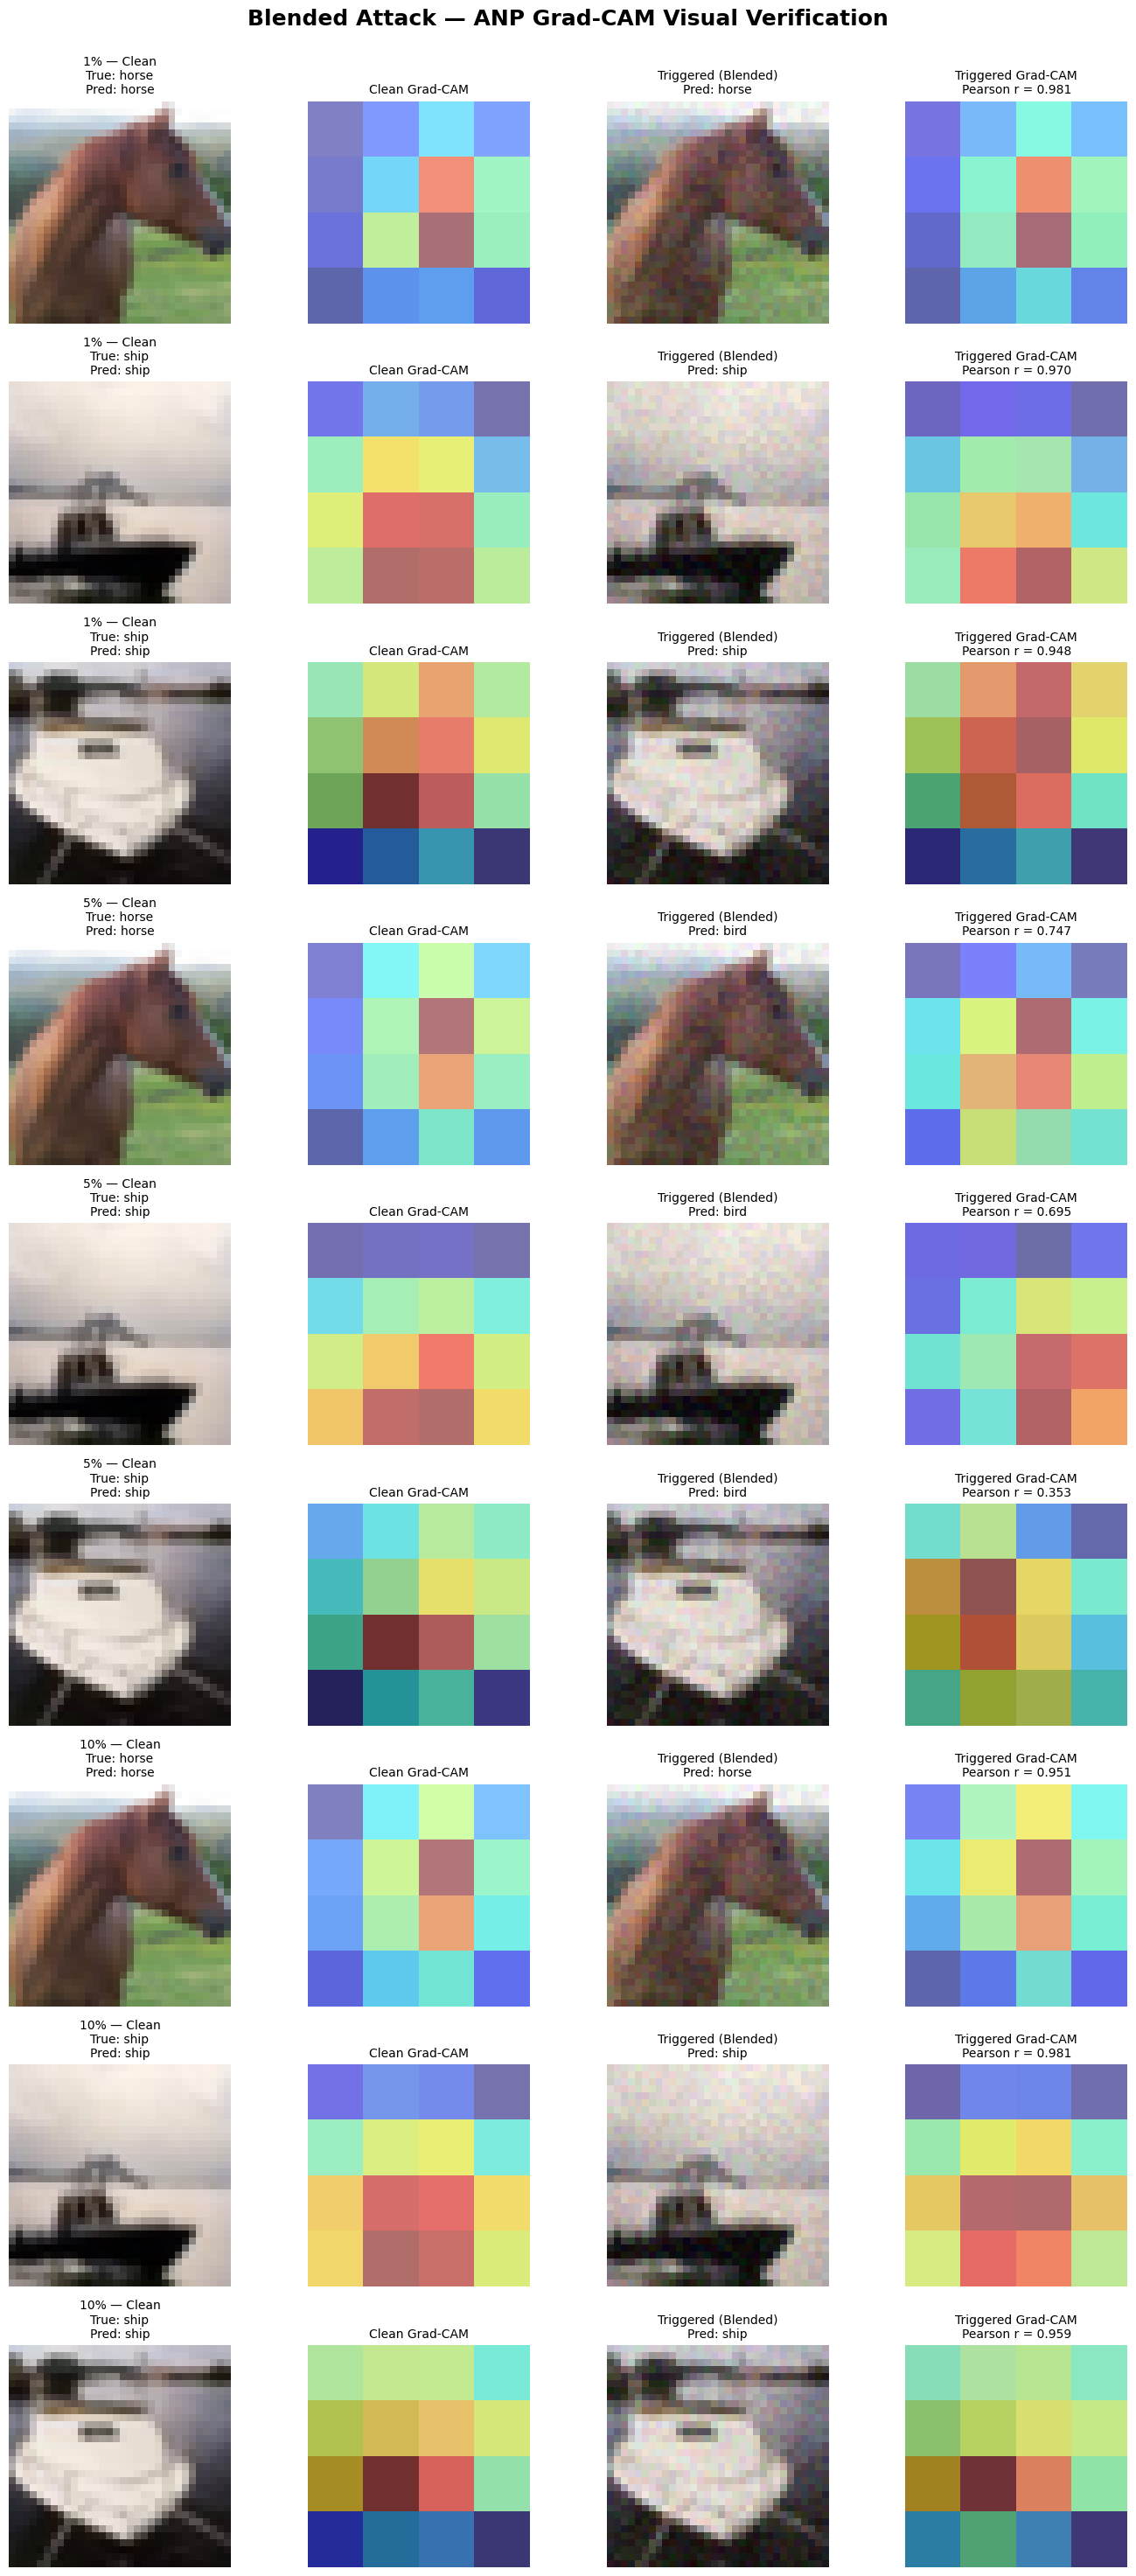

In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# BLENDED — ANP Grad-CAM VISUAL VERIFICATION
# DISPLAY ONLY — NOTHING SAVED
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import pearsonr
from IPython.display import display

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

N_VISUAL_SAMPLES = 3
POISON_RATES = ["1%", "5%", "10%"]


# ──────────────────────────────────────────────────────────────────────────────
# SAME 3 IMAGES FOR ALL POISON RATES
# ──────────────────────────────────────────────────────────────────────────────

rng = np.random.RandomState(CFG["SEED"])

vis_sample_indices = rng.choice(
    asr_test_idx,
    size=N_VISUAL_SAMPLES,
    replace=False
)

print("Selected test samples:", vis_sample_indices.tolist())


# ──────────────────────────────────────────────────────────────────────────────
# IMAGE → MODEL INPUT
# ──────────────────────────────────────────────────────────────────────────────

def to_tensor(img):

    img = img.astype(np.float32) / 255.0

    x = torch.from_numpy(img).permute(2, 0, 1)

    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)

    x = (x - mean) / std

    return x.unsqueeze(0).to(CFG["DEVICE"])


# ══════════════════════════════════════════════════════════════════════════════
# ONE LARGE FIGURE
#
#             Clean | Clean Grad-CAM | Triggered | Triggered Grad-CAM
#
# 1%          sample 1
#             sample 2
#             sample 3
#
# 5%          sample 1
#             sample 2
#             sample 3
#
# 10%         sample 1
#             sample 2
#             sample 3
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(
    9,
    4,
    figsize=(14, 30)
)

row = 0


for pr_label in POISON_RATES:

    print(
        f"\n{'=' * 60}\n"
        f"Grad-CAM — Blended {pr_label} ANP\n"
        f"{'=' * 60}"
    )

    # --------------------------------------------------------------
    # Load ANP model ONCE
    # --------------------------------------------------------------

    anp_path = checkpoint_registry[
        (pr_label, "anp")
    ]

    print("Loading ANP checkpoint...")

    model = load_checkpoint(anp_path)
    model.eval()


    for sample_idx in vis_sample_indices:

        # ----------------------------------------------------------
        # Original image
        # ----------------------------------------------------------

        clean_img = testset_raw.data[sample_idx]

        gt = testset_raw.targets[sample_idx]


        # ----------------------------------------------------------
        # Apply BLENDED trigger
        # ----------------------------------------------------------

        triggered_img = add_blended_trigger_global(
            clean_img.copy(),
            blend_pattern,
            CFG["ALPHA_TEST"]
        )


        # ----------------------------------------------------------
        # Convert to tensors
        # ----------------------------------------------------------

        clean_tensor = to_tensor(clean_img)

        triggered_tensor = to_tensor(triggered_img)


        # ----------------------------------------------------------
        # Grad-CAM — CLEAN
        # ----------------------------------------------------------

        clean_cam, clean_pred, _ = gradcam_heatmap(
            model,
            clean_tensor,
            model.layer4
        )


        # ----------------------------------------------------------
        # Grad-CAM — TRIGGERED
        # ----------------------------------------------------------

        triggered_cam, triggered_pred, _ = gradcam_heatmap(
            model,
            triggered_tensor,
            model.layer4
        )


        # ----------------------------------------------------------
        # Pearson correlation
        # ----------------------------------------------------------

        r, _ = pearsonr(
            clean_cam.flatten(),
            triggered_cam.flatten()
        )


        # ══════════════════════════════════════════════════════════
        # COLUMN 1 — CLEAN
        # ══════════════════════════════════════════════════════════

        axes[row, 0].imshow(clean_img)

        axes[row, 0].set_title(
            f"{pr_label} — Clean\n"
            f"True: {CIFAR10_CLASSES[gt]}\n"
            f"Pred: {CIFAR10_CLASSES[clean_pred]}",
            fontsize=10
        )

        axes[row, 0].axis("off")


        # ══════════════════════════════════════════════════════════
        # COLUMN 2 — CLEAN GRAD-CAM
        # ══════════════════════════════════════════════════════════

        axes[row, 1].imshow(clean_img)

        axes[row, 1].imshow(
            clean_cam,
            cmap="jet",
            alpha=0.5
        )

        axes[row, 1].set_title(
            "Clean Grad-CAM",
            fontsize=10
        )

        axes[row, 1].axis("off")


        # ══════════════════════════════════════════════════════════
        # COLUMN 3 — TRIGGERED
        # ══════════════════════════════════════════════════════════

        axes[row, 2].imshow(triggered_img)

        axes[row, 2].set_title(
            f"Triggered (Blended)\n"
            f"Pred: {CIFAR10_CLASSES[triggered_pred]}",
            fontsize=10,
            color=(
                "red"
                if triggered_pred == CFG["TARGET_CLASS"]
                else "black"
            )
        )

        axes[row, 2].axis("off")


        # ══════════════════════════════════════════════════════════
        # COLUMN 4 — TRIGGERED GRAD-CAM
        # ══════════════════════════════════════════════════════════

        axes[row, 3].imshow(triggered_img)

        axes[row, 3].imshow(
            triggered_cam,
            cmap="jet",
            alpha=0.5
        )

        axes[row, 3].set_title(
            f"Triggered Grad-CAM\n"
            f"Pearson r = {r:.3f}",
            fontsize=10
        )

        axes[row, 3].axis("off")


        row += 1


    # --------------------------------------------------------------
    # Cleanup after each poison rate
    # --------------------------------------------------------------

    del model
    torch.cuda.empty_cache()


# ══════════════════════════════════════════════════════════════════════════════
# FINAL TITLE
# ══════════════════════════════════════════════════════════════════════════════

fig.suptitle(
    "Blended Attack — ANP Grad-CAM Visual Verification",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)


# ══════════════════════════════════════════════════════════════════════════════
# FORCE DISPLAY IN COLAB
# ══════════════════════════════════════════════════════════════════════════════

display(fig)

plt.close(fig)

Selected test samples: [9167, 9083]

Grad-CAM Visualization — Blended 1%
  Loading 1% baseline + ANP checkpoints...
  Loading 1% baseline + ANP checkpoints...

Grad-CAM Visualization — Blended 5%
  Loading 5% baseline + ANP checkpoints...
  Loading 5% baseline + ANP checkpoints...

Grad-CAM Visualization — Blended 10%
  Loading 10% baseline + ANP checkpoints...
  Loading 10% baseline + ANP checkpoints...


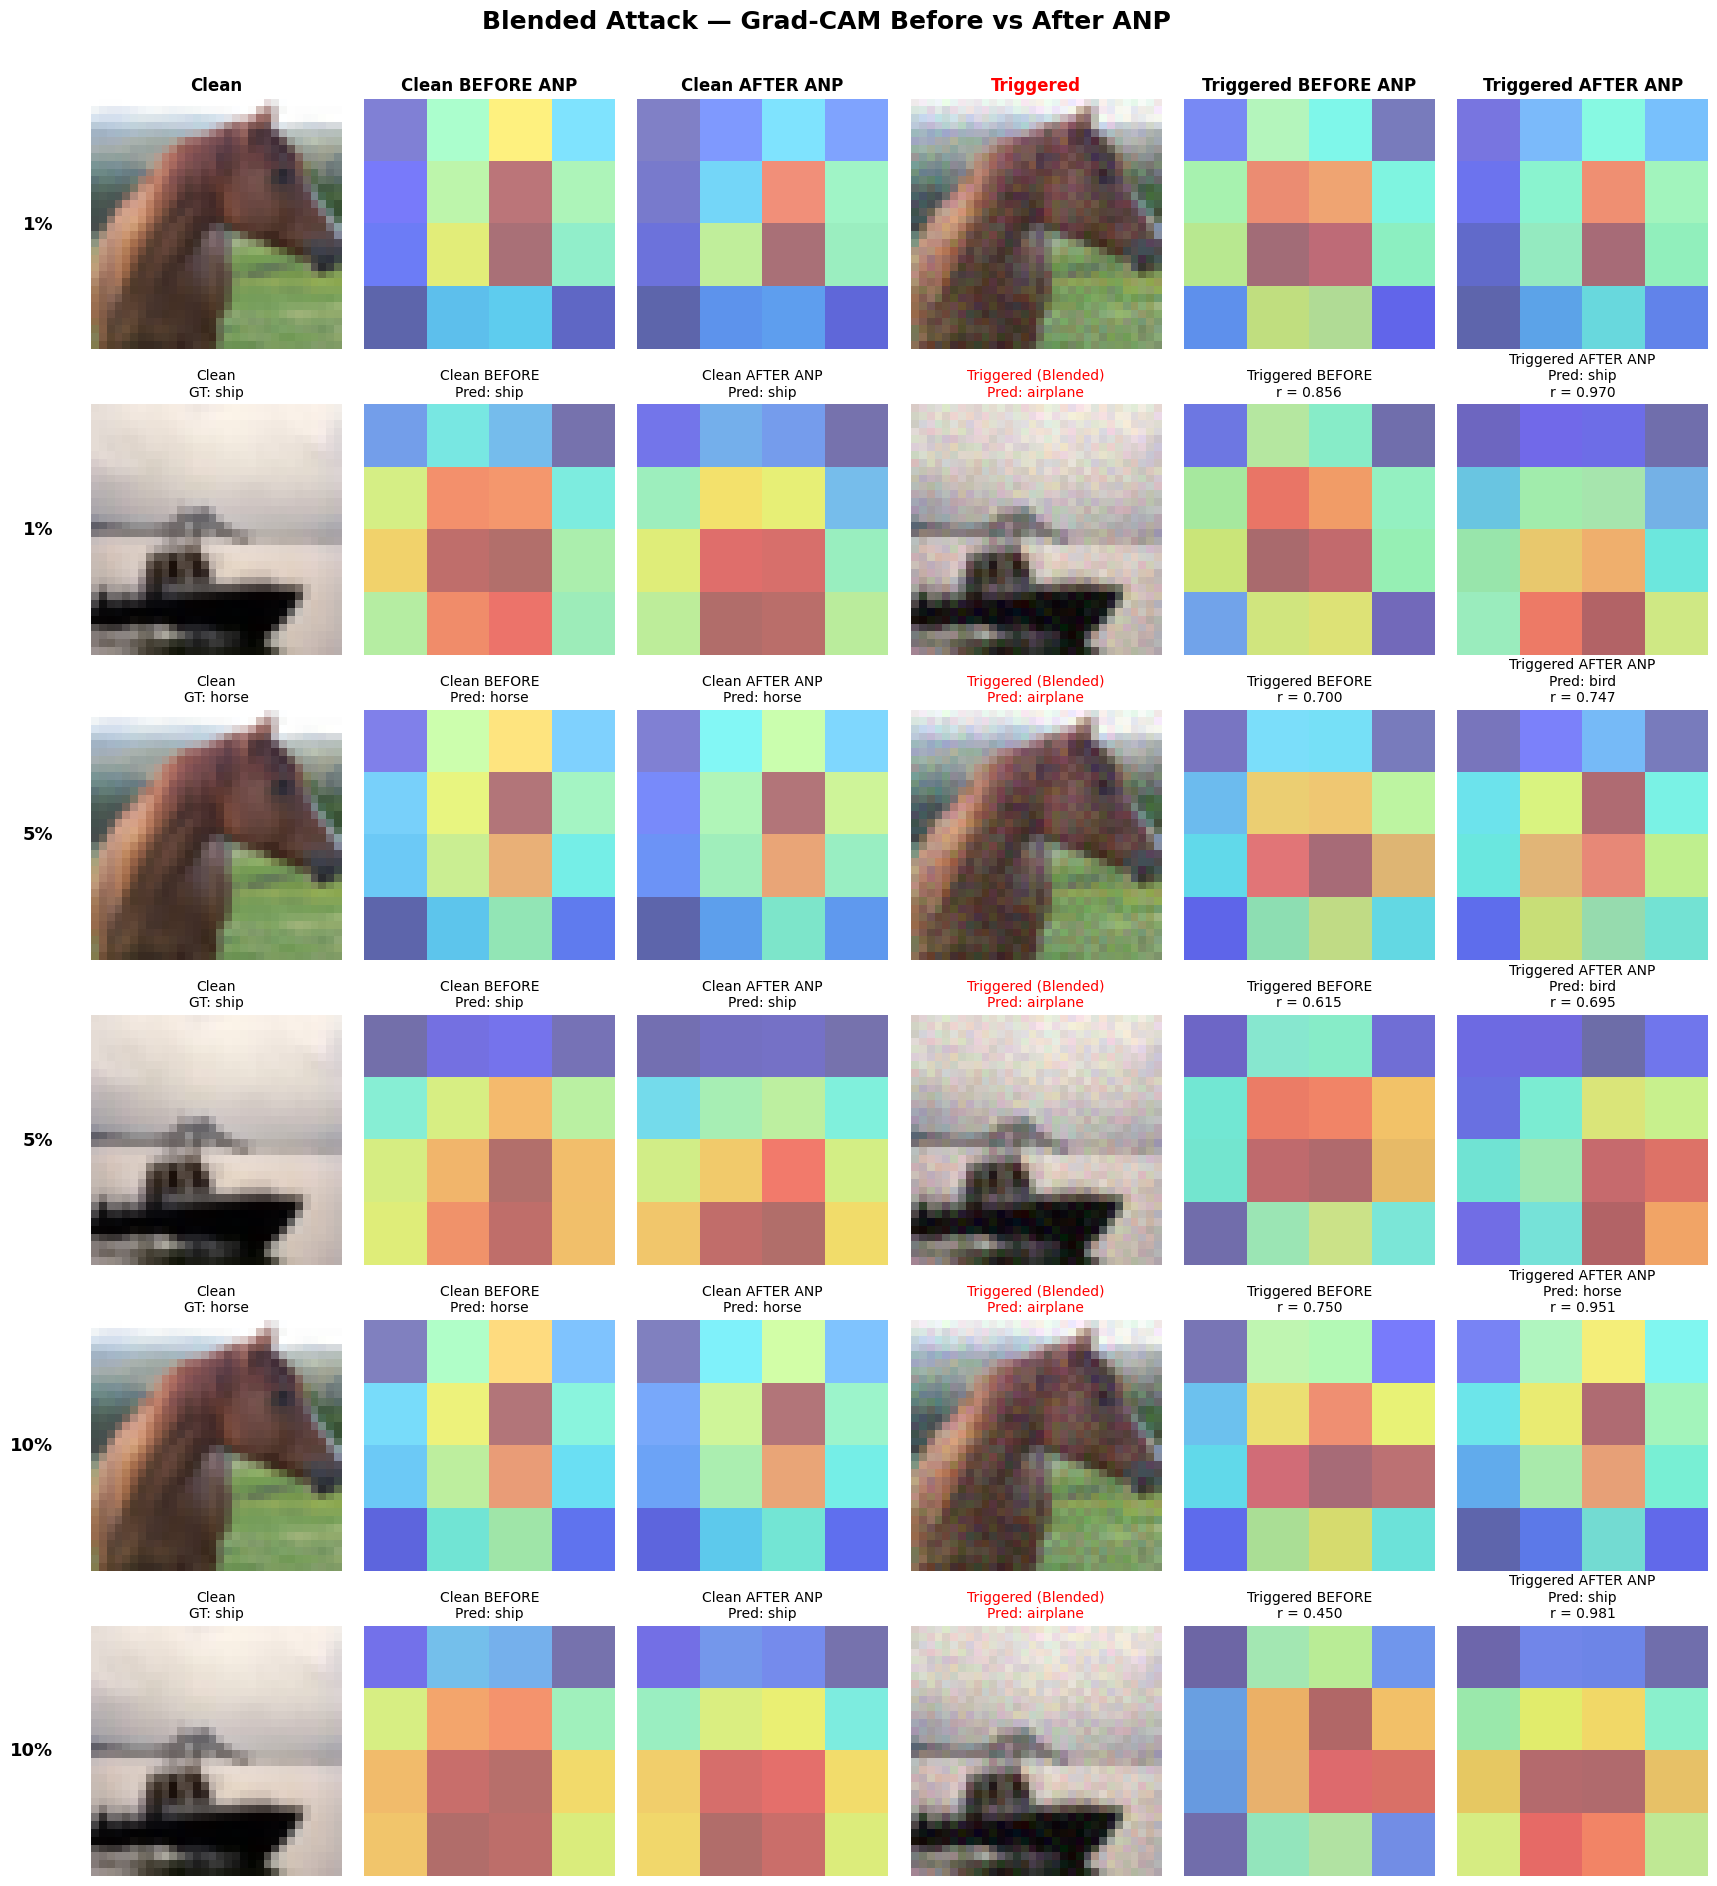

In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# BLENDED ATTACK — COMPLETE VISUAL VERIFICATION
# 1%, 5%, 10% — BEFORE vs AFTER ANP
#
# Layout:
#   Clean | Clean BEFORE | Clean AFTER | Triggered | Triggered BEFORE | Triggered AFTER
#
# Also displays:
#   ASR Before vs After ANP
#   CA Before vs After ANP
#
# NOTHING IS SAVED TO DRIVE
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import pearsonr
from IPython.display import display

CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

POISON_RATES = ["1%", "5%", "10%"]
N_SAMPLES = 2


# ══════════════════════════════════════════════════════════════════════════════
# SELECT SAME TEST IMAGES FOR ALL POISON RATES
# ══════════════════════════════════════════════════════════════════════════════

rng = np.random.RandomState(CFG["SEED"])

visual_indices = rng.choice(
    asr_test_idx,
    size=N_SAMPLES,
    replace=False
)

print("Selected test samples:", visual_indices.tolist())


# ══════════════════════════════════════════════════════════════════════════════
# CONVERT CIFAR IMAGE → MODEL INPUT
# ══════════════════════════════════════════════════════════════════════════════

def blended_to_tensor(img):

    img = img.astype(np.float32) / 255.0

    x = torch.from_numpy(img).permute(2, 0, 1)

    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)

    x = (x - mean) / std

    return x.unsqueeze(0).to(CFG["DEVICE"])


# ══════════════════════════════════════════════════════════════════════════════
# GET BEFORE / AFTER GRAD-CAM
# ══════════════════════════════════════════════════════════════════════════════

def get_visual_result(pr_label, sample_idx):

    baseline_path = checkpoint_registry[(pr_label, "baseline")]
    anp_path = checkpoint_registry[(pr_label, "anp")]

    print(f"  Loading {pr_label} baseline + ANP checkpoints...")

    baseline_model = load_checkpoint(baseline_path)
    anp_model = load_checkpoint(anp_path)

    baseline_model.eval()
    anp_model.eval()

    # ----------------------------------------------------------
    # Images
    # ----------------------------------------------------------

    clean_img = testset_raw.data[sample_idx]

    triggered_img = add_blended_trigger_global(
        clean_img.copy(),
        blend_pattern,
        CFG["ALPHA_TEST"]
    )

    clean_tensor = blended_to_tensor(clean_img)
    triggered_tensor = blended_to_tensor(triggered_img)

    # ----------------------------------------------------------
    # BASELINE — CLEAN
    # ----------------------------------------------------------

    clean_before, pred_clean_before, _ = gradcam_heatmap(
        baseline_model,
        clean_tensor,
        baseline_model.layer4
    )

    # ----------------------------------------------------------
    # BASELINE — TRIGGERED
    # ----------------------------------------------------------

    triggered_before, pred_trigger_before, _ = gradcam_heatmap(
        baseline_model,
        triggered_tensor,
        baseline_model.layer4
    )

    # ----------------------------------------------------------
    # ANP — CLEAN
    # ----------------------------------------------------------

    clean_after, pred_clean_after, _ = gradcam_heatmap(
        anp_model,
        clean_tensor,
        anp_model.layer4
    )

    # ----------------------------------------------------------
    # ANP — TRIGGERED
    # ----------------------------------------------------------

    triggered_after, pred_trigger_after, _ = gradcam_heatmap(
        anp_model,
        triggered_tensor,
        anp_model.layer4
    )

    # ----------------------------------------------------------
    # Pearson correlations
    # ----------------------------------------------------------

    r_before, _ = pearsonr(
        clean_before.flatten(),
        triggered_before.flatten()
    )

    r_after, _ = pearsonr(
        clean_after.flatten(),
        triggered_after.flatten()
    )

    del baseline_model
    del anp_model
    torch.cuda.empty_cache()

    return {
        "clean_img": clean_img,
        "triggered_img": triggered_img,

        "clean_before": clean_before,
        "triggered_before": triggered_before,

        "clean_after": clean_after,
        "triggered_after": triggered_after,

        "pred_clean_before": pred_clean_before,
        "pred_trigger_before": pred_trigger_before,

        "pred_clean_after": pred_clean_after,
        "pred_trigger_after": pred_trigger_after,

        "r_before": r_before,
        "r_after": r_after
    }


# ══════════════════════════════════════════════════════════════════════════════
# CREATE ONE LARGE FIGURE
# ══════════════════════════════════════════════════════════════════════════════
#
# For each poison rate:
#
#   Sample 1
#   Sample 2
#
# Columns:
#
#   0 Clean
#   1 Clean BEFORE
#   2 Clean AFTER ANP
#   3 Triggered
#   4 Triggered BEFORE
#   5 Triggered AFTER ANP
#
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(
    len(POISON_RATES) * N_SAMPLES,
    6,
    figsize=(18, 3.2 * len(POISON_RATES) * N_SAMPLES)
)

axes = np.atleast_2d(axes)

row = 0


for pr_label in POISON_RATES:

    print(
        f"\n{'=' * 70}\n"
        f"Grad-CAM Visualization — Blended {pr_label}\n"
        f"{'=' * 70}"
    )

    for sample_idx in visual_indices:

        result = get_visual_result(
            pr_label,
            sample_idx
        )

        clean = result["clean_img"]
        triggered = result["triggered_img"]

        gt = testset_raw.targets[sample_idx]

        # ══════════════════════════════════════════════════════════════════════
        # 1. CLEAN IMAGE
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 0].imshow(clean)

        axes[row, 0].set_title(
            f"Clean\n"
            f"GT: {CIFAR_CLASSES[gt]}",
            fontsize=10
        )

        axes[row, 0].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # 2. CLEAN BEFORE ANP
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 1].imshow(clean)

        axes[row, 1].imshow(
            result["clean_before"],
            cmap="jet",
            alpha=0.5
        )

        axes[row, 1].set_title(
            f"Clean BEFORE\n"
            f"Pred: {CIFAR_CLASSES[result['pred_clean_before']]}",
            fontsize=10
        )

        axes[row, 1].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # 3. CLEAN AFTER ANP
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 2].imshow(clean)

        axes[row, 2].imshow(
            result["clean_after"],
            cmap="jet",
            alpha=0.5
        )

        axes[row, 2].set_title(
            f"Clean AFTER ANP\n"
            f"Pred: {CIFAR_CLASSES[result['pred_clean_after']]}",
            fontsize=10
        )

        axes[row, 2].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # 4. TRIGGERED IMAGE
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 3].imshow(triggered)

        attack_success = (
            result["pred_trigger_before"]
            == CFG["TARGET_CLASS"]
        )

        axes[row, 3].set_title(
            f"Triggered (Blended)\n"
            f"Pred: {CIFAR_CLASSES[result['pred_trigger_before']]}",
            fontsize=10,
            color="red" if attack_success else "black"
        )

        axes[row, 3].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # 5. TRIGGERED BEFORE ANP
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 4].imshow(triggered)

        axes[row, 4].imshow(
            result["triggered_before"],
            cmap="jet",
            alpha=0.5
        )

        axes[row, 4].set_title(
            f"Triggered BEFORE\n"
            f"r = {result['r_before']:.3f}",
            fontsize=10
        )

        axes[row, 4].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # 6. TRIGGERED AFTER ANP
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 5].imshow(triggered)

        axes[row, 5].imshow(
            result["triggered_after"],
            cmap="jet",
            alpha=0.5
        )

        axes[row, 5].set_title(
            f"Triggered AFTER ANP\n"
            f"Pred: {CIFAR_CLASSES[result['pred_trigger_after']]}\n"
            f"r = {result['r_after']:.3f}",
            fontsize=10
        )

        axes[row, 5].axis("off")


        # ──────────────────────────────────────────────────────────────────────
        # Label poison rate on first column
        # ──────────────────────────────────────────────────────────────────────

        axes[row, 0].text(
            -0.15,
            0.5,
            pr_label,
            transform=axes[row, 0].transAxes,
            fontsize=13,
            fontweight="bold",
            va="center",
            ha="right"
        )

        row += 1


# ══════════════════════════════════════════════════════════════════════════════
# COLUMN HEADERS
# ══════════════════════════════════════════════════════════════════════════════

axes[0, 0].set_title("Clean", fontsize=12, fontweight="bold")
axes[0, 1].set_title("Clean BEFORE ANP", fontsize=12, fontweight="bold")
axes[0, 2].set_title("Clean AFTER ANP", fontsize=12, fontweight="bold")
axes[0, 3].set_title("Triggered", fontsize=12, fontweight="bold")
axes[0, 4].set_title("Triggered BEFORE ANP", fontsize=12, fontweight="bold")
axes[0, 5].set_title("Triggered AFTER ANP", fontsize=12, fontweight="bold")


fig.suptitle(
    "Blended Attack — Grad-CAM Before vs After ANP",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0.04, 0, 1, 0.97]
)

display(fig)

plt.close(fig)

Selected test samples: [9167, 9083]

Grad-CAM Visualization — Blended 1%
    Loading 1% baseline...
    Loading 1% ANP...
    Loading 1% baseline...
    Loading 1% ANP...

Grad-CAM Visualization — Blended 5%
    Loading 5% baseline...
    Loading 5% ANP...
    Loading 5% baseline...
    Loading 5% ANP...

Grad-CAM Visualization — Blended 10%
    Loading 10% baseline...
    Loading 10% ANP...
    Loading 10% baseline...
    Loading 10% ANP...


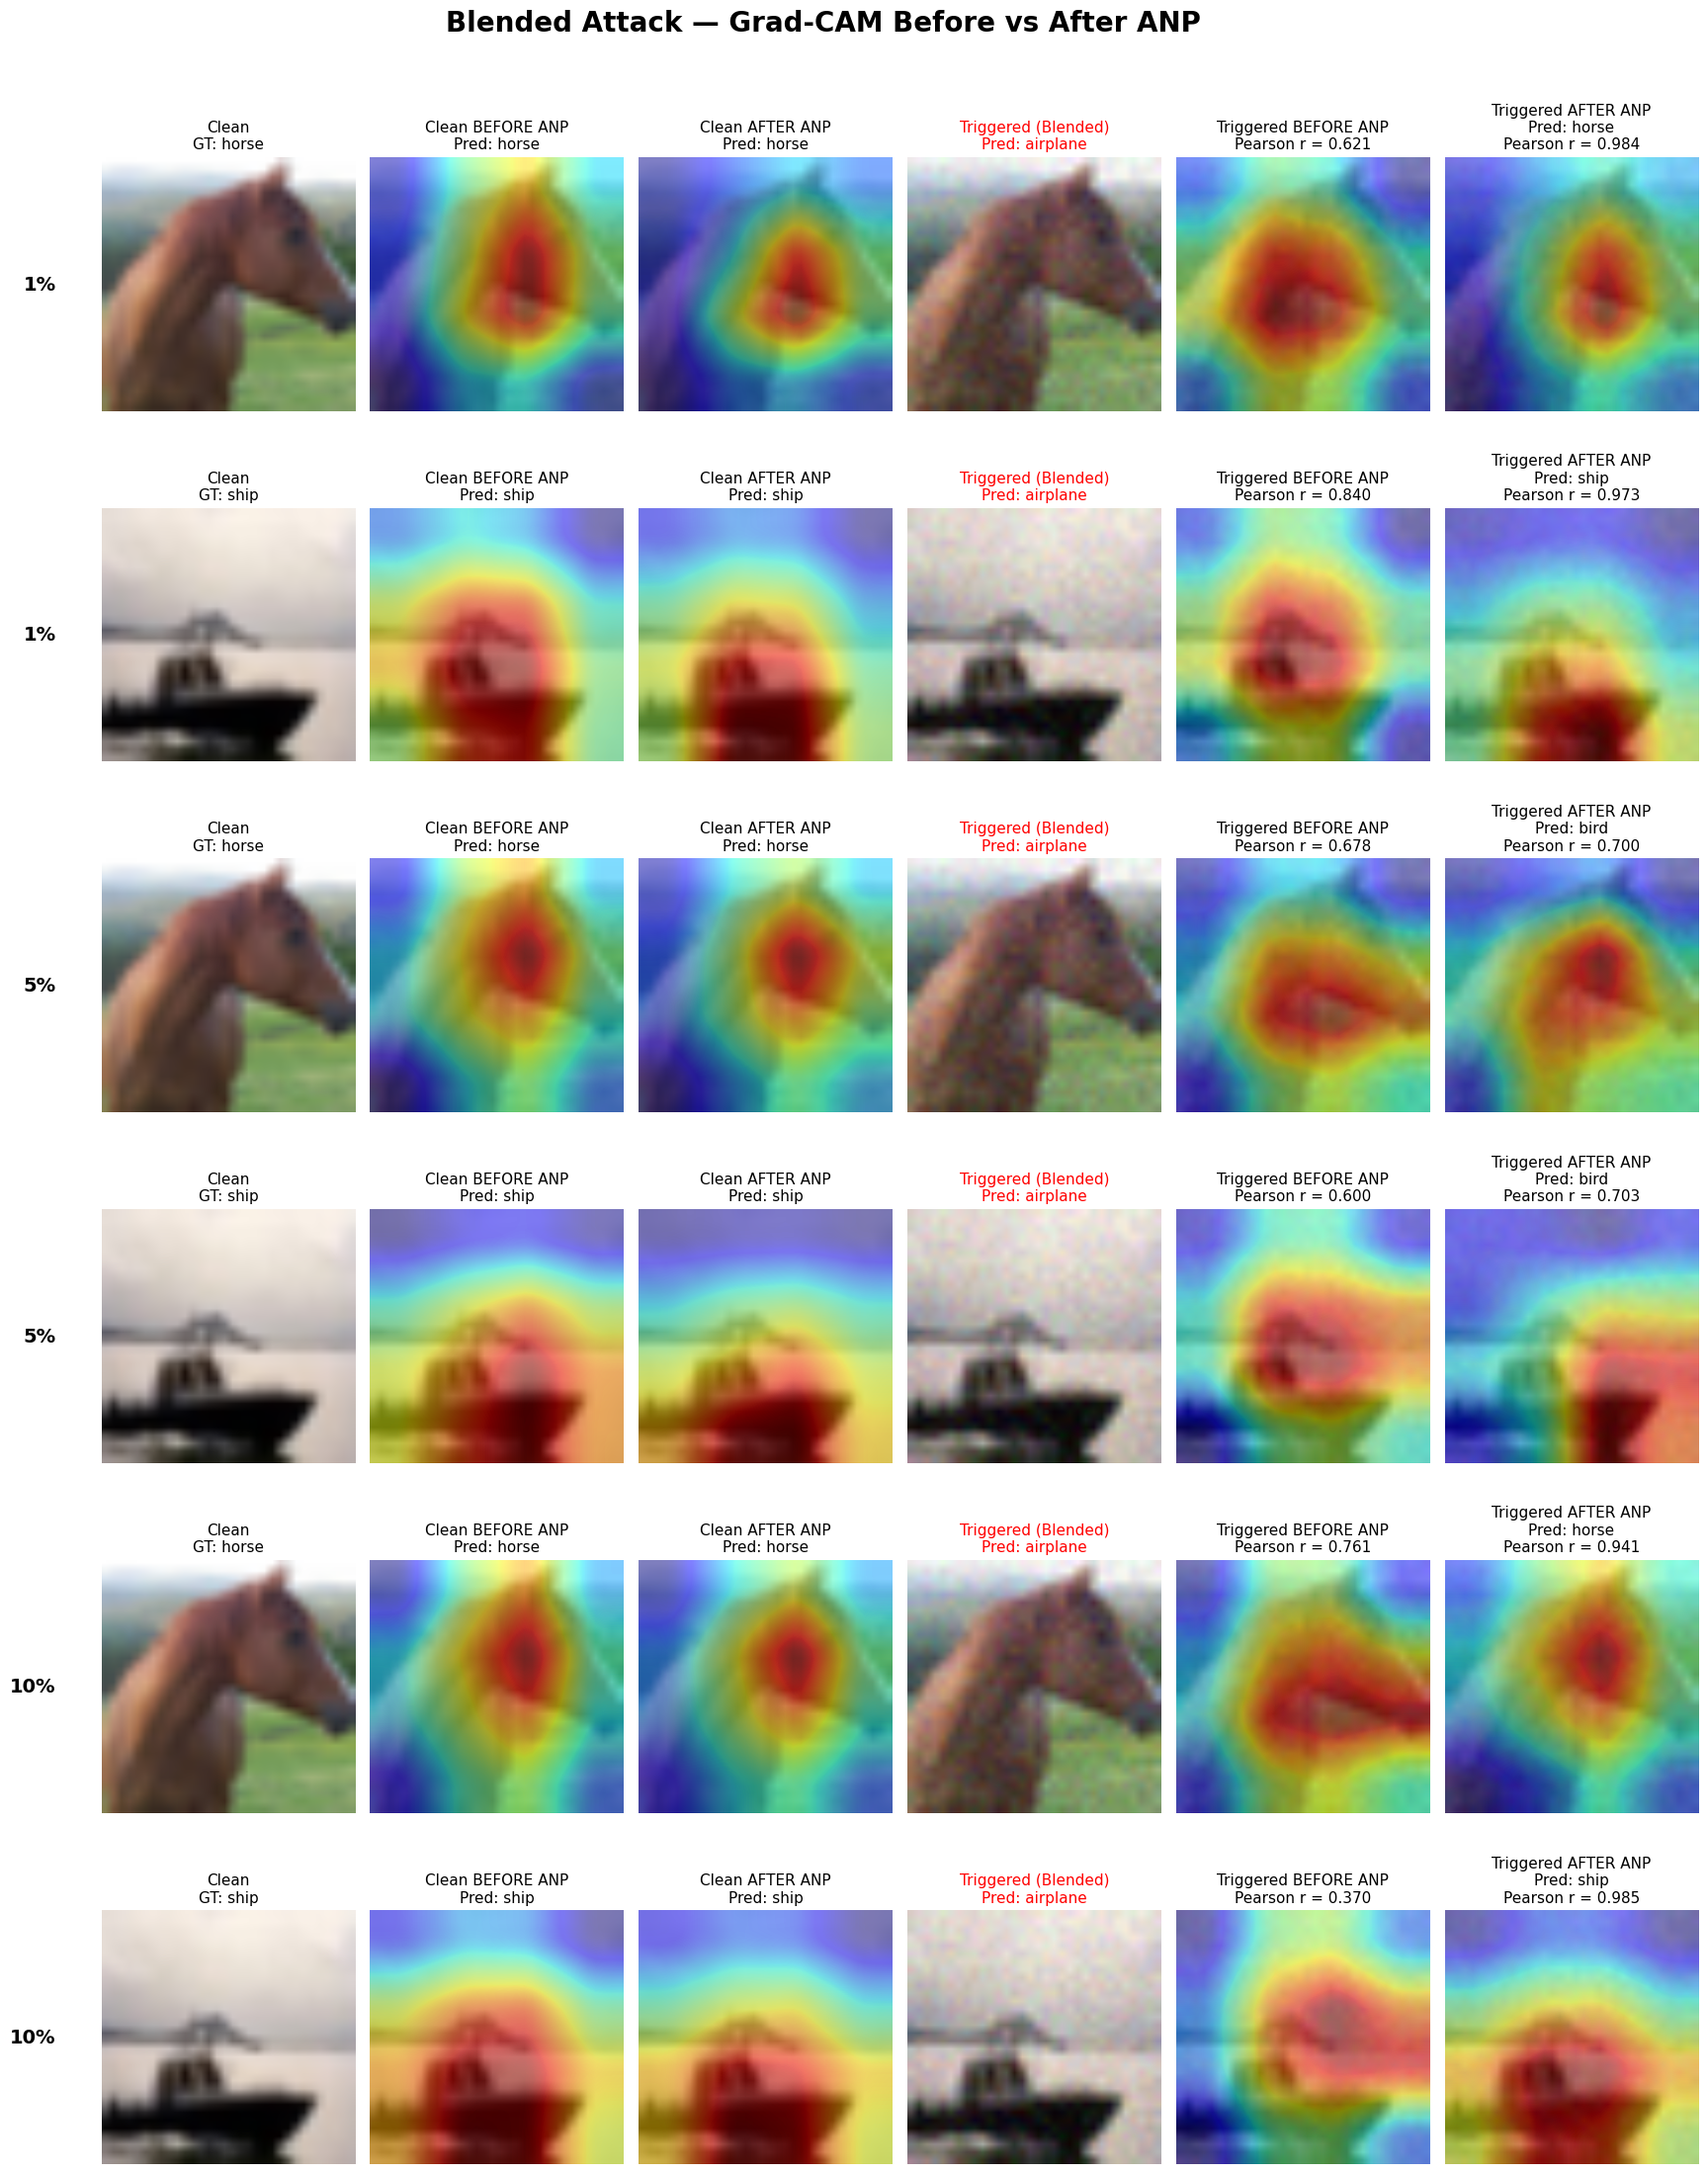


✔ Grad-CAM visual verification displayed.
✔ Nothing was saved to Google Drive.


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# BLENDED ATTACK — GRAD-CAM VISUAL VERIFICATION
# BEFORE vs AFTER ANP
#
# Poison rates: 1%, 5%, 10%
#
# DISPLAY ONLY — NOTHING IS SAVED TO GOOGLE DRIVE
#
# Layout:
#
# Clean | Clean BEFORE | Clean AFTER | Triggered | Triggered BEFORE | Triggered AFTER
#
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy.stats import pearsonr
from IPython.display import display

# ──────────────────────────────────────────────────────────────────────────────
# CIFAR-10 class names
# ──────────────────────────────────────────────────────────────────────────────

CIFAR_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

POISON_RATES = ["1%", "5%", "10%"]

# Number of examples for each poison rate
N_VISUAL_SAMPLES = 2


# ══════════════════════════════════════════════════════════════════════════════
# 1. SELECT TEST SAMPLES
# ══════════════════════════════════════════════════════════════════════════════

rng = np.random.RandomState(CFG["SEED"])

visual_indices = rng.choice(
    asr_test_idx,
    size=N_VISUAL_SAMPLES,
    replace=False
)

print("Selected test samples:", visual_indices.tolist())


# ══════════════════════════════════════════════════════════════════════════════
# 2. IMAGE → MODEL INPUT
# ══════════════════════════════════════════════════════════════════════════════

def blended_to_tensor(img):

    img = img.astype(np.float32) / 255.0

    x = torch.from_numpy(img).permute(2, 0, 1)

    mean = torch.tensor(
        CIFAR_MEAN,
        dtype=torch.float32
    ).view(3, 1, 1)

    std = torch.tensor(
        CIFAR_STD,
        dtype=torch.float32
    ).view(3, 1, 1)

    x = (x - mean) / std

    return x.unsqueeze(0).to(CFG["DEVICE"])


# ══════════════════════════════════════════════════════════════════════════════
# 3. GRAD-CAM
#
# IMPORTANT:
#
# ResNet-18 layer4 produces approximately a 4×4 feature map for CIFAR-10.
#
# We explicitly resize:
#
#       4 × 4
#         ↓
#    bilinear interpolation
#         ↓
#       32 × 32
#
# This is what gives the smooth heatmap instead of the obvious 4×4 blocks.
# ══════════════════════════════════════════════════════════════════════════════

def gradcam_visual(model, input_tensor):

    model.eval()

    activations = None
    gradients = None

    # ----------------------------------------------------------
    # Hooks
    # ----------------------------------------------------------

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    handle_forward = model.layer4.register_forward_hook(
        forward_hook
    )

    handle_backward = model.layer4.register_full_backward_hook(
        backward_hook
    )

    try:

        # ------------------------------------------------------
        # Enable gradients explicitly
        # ------------------------------------------------------

        with torch.enable_grad():

            model.zero_grad(set_to_none=True)

            output = model(input_tensor)

            # Use the model's predicted class
            predicted_class = output.argmax(
                dim=1
            ).item()

            score = output[0, predicted_class]

            score.backward()

            # --------------------------------------------------
            # Grad-CAM weights
            # --------------------------------------------------

            weights = gradients.mean(
                dim=(2, 3),
                keepdim=True
            )

            cam = (
                weights * activations
            ).sum(
                dim=1,
                keepdim=True
            )

            # --------------------------------------------------
            # ReLU
            # --------------------------------------------------

            cam = F.relu(cam)

            # ==================================================
            # IMPORTANT FIX
            #
            # Explicitly resize the CAM to 32×32
            # ==================================================

            cam = F.interpolate(
                cam,
                size=(32, 32),
                mode="bilinear",
                align_corners=False
            )

            # --------------------------------------------------
            # Convert to numpy
            # --------------------------------------------------

            cam = cam.squeeze().detach().cpu().numpy()

            # --------------------------------------------------
            # Normalize
            # --------------------------------------------------

            cam_min = cam.min()
            cam_max = cam.max()

            if cam_max > cam_min:

                cam = (
                    cam - cam_min
                ) / (
                    cam_max - cam_min
                )

            else:

                cam = np.zeros_like(cam)

            # --------------------------------------------------
            # Optional slight smoothing
            #
            # This only improves visualization.
            # It does NOT change the Grad-CAM calculation.
            # --------------------------------------------------

            from scipy.ndimage import gaussian_filter

            cam = gaussian_filter(
                cam,
                sigma=0.8
            )

            # Normalize again after smoothing

            cam_min = cam.min()
            cam_max = cam.max()

            if cam_max > cam_min:

                cam = (
                    cam - cam_min
                ) / (
                    cam_max - cam_min
                )

            return cam, predicted_class

    finally:

        handle_forward.remove()
        handle_backward.remove()

        model.zero_grad(set_to_none=True)


# ══════════════════════════════════════════════════════════════════════════════
# 4. LOAD MODELS + GENERATE VISUALS
# ══════════════════════════════════════════════════════════════════════════════

def get_blended_visuals(pr_label, sample_idx):

    # ----------------------------------------------------------
    # Get checkpoints
    # ----------------------------------------------------------

    baseline_path = checkpoint_registry[
        (pr_label, "baseline")
    ]

    anp_path = checkpoint_registry[
        (pr_label, "anp")
    ]

    print(
        f"    Loading {pr_label} baseline..."
    )

    baseline_model = load_checkpoint(
        baseline_path
    )

    print(
        f"    Loading {pr_label} ANP..."
    )

    anp_model = load_checkpoint(
        anp_path
    )

    baseline_model.eval()
    anp_model.eval()

    # ----------------------------------------------------------
    # Original image
    # ----------------------------------------------------------

    clean_img = testset_raw.data[
        sample_idx
    ]

    gt_class = testset_raw.targets[
        sample_idx
    ]

    # ----------------------------------------------------------
    # Blended trigger
    # ----------------------------------------------------------

    triggered_img = add_blended_trigger_global(
        clean_img.copy(),
        blend_pattern,
        CFG["ALPHA_TEST"]
    )

    # ----------------------------------------------------------
    # Convert to tensors
    # ----------------------------------------------------------

    clean_tensor = blended_to_tensor(
        clean_img
    )

    triggered_tensor = blended_to_tensor(
        triggered_img
    )

    # ══════════════════════════════════════════════════════════════════════════
    # BASELINE — CLEAN
    # ══════════════════════════════════════════════════════════════════════════

    clean_before_cam, clean_before_pred = gradcam_visual(
        baseline_model,
        clean_tensor
    )

    # ══════════════════════════════════════════════════════════════════════════
    # BASELINE — TRIGGERED
    # ══════════════════════════════════════════════════════════════════════════

    triggered_before_cam, triggered_before_pred = gradcam_visual(
        baseline_model,
        triggered_tensor
    )

    # ══════════════════════════════════════════════════════════════════════════
    # ANP — CLEAN
    # ══════════════════════════════════════════════════════════════════════════

    clean_after_cam, clean_after_pred = gradcam_visual(
        anp_model,
        clean_tensor
    )

    # ══════════════════════════════════════════════════════════════════════════
    # ANP — TRIGGERED
    # ══════════════════════════════════════════════════════════════════════════

    triggered_after_cam, triggered_after_pred = gradcam_visual(
        anp_model,
        triggered_tensor
    )

    # ----------------------------------------------------------
    # Pearson correlations
    # ----------------------------------------------------------

    r_before, _ = pearsonr(
        clean_before_cam.flatten(),
        triggered_before_cam.flatten()
    )

    r_after, _ = pearsonr(
        clean_after_cam.flatten(),
        triggered_after_cam.flatten()
    )

    # ----------------------------------------------------------
    # Cleanup
    # ----------------------------------------------------------

    del baseline_model
    del anp_model

    torch.cuda.empty_cache()

    return {

        "clean_img": clean_img,
        "triggered_img": triggered_img,

        "gt_class": gt_class,

        "clean_before_cam": clean_before_cam,
        "triggered_before_cam": triggered_before_cam,

        "clean_after_cam": clean_after_cam,
        "triggered_after_cam": triggered_after_cam,

        "clean_before_pred": clean_before_pred,
        "triggered_before_pred": triggered_before_pred,

        "clean_after_pred": clean_after_pred,
        "triggered_after_pred": triggered_after_pred,

        "r_before": r_before,
        "r_after": r_after
    }


# ══════════════════════════════════════════════════════════════════════════════
# 5. CREATE ONE LARGE FIGURE
# ══════════════════════════════════════════════════════════════════════════════
#
# Each row:
#
#   Clean
#   Clean BEFORE ANP
#   Clean AFTER ANP
#   Triggered
#   Triggered BEFORE ANP
#   Triggered AFTER ANP
#
# ══════════════════════════════════════════════════════════════════════════════

TOTAL_ROWS = len(POISON_RATES) * N_VISUAL_SAMPLES

fig, axes = plt.subplots(
    TOTAL_ROWS,
    6,
    figsize=(18, 3.8 * TOTAL_ROWS)
)

axes = np.atleast_2d(axes)

row = 0


for pr_label in POISON_RATES:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Grad-CAM Visualization — Blended {pr_label}"
    )

    print(
        "=" * 70
    )

    for sample_idx in visual_indices:

        result = get_blended_visuals(
            pr_label,
            sample_idx
        )

        clean = result["clean_img"]
        triggered = result["triggered_img"]

        gt = result["gt_class"]


        # ══════════════════════════════════════════════════════════════════════
        # COLUMN 1 — CLEAN IMAGE
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 0].imshow(
            clean,
            interpolation="bilinear"
        )

        axes[row, 0].set_title(
            f"Clean\n"
            f"GT: {CIFAR_CLASSES[gt]}",
            fontsize=11
        )

        axes[row, 0].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # COLUMN 2 — CLEAN BEFORE ANP
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 1].imshow(
            clean,
            interpolation="bilinear"
        )

        axes[row, 1].imshow(
            result["clean_before_cam"],
            cmap="jet",
            alpha=0.50,
            interpolation="bilinear"
        )

        axes[row, 1].set_title(
            f"Clean BEFORE ANP\n"
            f"Pred: {CIFAR_CLASSES[result['clean_before_pred']]}",
            fontsize=11
        )

        axes[row, 1].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # COLUMN 3 — CLEAN AFTER ANP
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 2].imshow(
            clean,
            interpolation="bilinear"
        )

        axes[row, 2].imshow(
            result["clean_after_cam"],
            cmap="jet",
            alpha=0.50,
            interpolation="bilinear"
        )

        axes[row, 2].set_title(
            f"Clean AFTER ANP\n"
            f"Pred: {CIFAR_CLASSES[result['clean_after_pred']]}",
            fontsize=11
        )

        axes[row, 2].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # COLUMN 4 — TRIGGERED IMAGE
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 3].imshow(
            triggered,
            interpolation="bilinear"
        )

        axes[row, 3].set_title(
            f"Triggered (Blended)\n"
            f"Pred: {CIFAR_CLASSES[result['triggered_before_pred']]}",
            fontsize=11,
            color=(
                "red"
                if result["triggered_before_pred"]
                == CFG["TARGET_CLASS"]
                else "black"
            )
        )

        axes[row, 3].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # COLUMN 5 — TRIGGERED BEFORE ANP
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 4].imshow(
            triggered,
            interpolation="bilinear"
        )

        axes[row, 4].imshow(
            result["triggered_before_cam"],
            cmap="jet",
            alpha=0.50,
            interpolation="bilinear"
        )

        axes[row, 4].set_title(
            f"Triggered BEFORE ANP\n"
            f"Pearson r = {result['r_before']:.3f}",
            fontsize=11
        )

        axes[row, 4].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # COLUMN 6 — TRIGGERED AFTER ANP
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 5].imshow(
            triggered,
            interpolation="bilinear"
        )

        axes[row, 5].imshow(
            result["triggered_after_cam"],
            cmap="jet",
            alpha=0.50,
            interpolation="bilinear"
        )

        axes[row, 5].set_title(
            f"Triggered AFTER ANP\n"
            f"Pred: {CIFAR_CLASSES[result['triggered_after_pred']]}\n"
            f"Pearson r = {result['r_after']:.3f}",
            fontsize=11
        )

        axes[row, 5].axis("off")


        # ══════════════════════════════════════════════════════════════════════
        # POISON RATE LABEL
        # ══════════════════════════════════════════════════════════════════════

        axes[row, 0].text(
            -0.18,
            0.50,
            pr_label,
            transform=axes[row, 0].transAxes,
            fontsize=14,
            fontweight="bold",
            va="center",
            ha="right"
        )

        row += 1


# ══════════════════════════════════════════════════════════════════════════════
# 6. FINAL FIGURE FORMATTING
# ══════════════════════════════════════════════════════════════════════════════

fig.suptitle(
    "Blended Attack — Grad-CAM Before vs After ANP",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0.04, 0, 1, 0.97]
)


# ══════════════════════════════════════════════════════════════════════════════
# 7. DISPLAY DIRECTLY IN NOTEBOOK
# ══════════════════════════════════════════════════════════════════════════════

display(fig)

plt.close(fig)

print("\n✔ Grad-CAM visual verification displayed.")
print("✔ Nothing was saved to Google Drive.")